# Pathwise convergence of formula (31) — ex-3 (**mono** duplicate)

Single-color duplicate: all per-factor boxplots share one color and the band-figure
measured dots carry no CI caps. Sweeps load from the shared
`nb_outputs/ex2v2_df_{p,n}.parquet` cache (identical model/design/seed); figures
write to `nb_outputs/mono-ex3/`.

The convergence claim of Corollary 1 is almost sure, i.e. pathwise. Prior figures
(ex-2c) compare **means** across replicates, which can hide per-path variance. Here
each comparison is computed per replicate first, then its distribution shown as boxplots.

Formula (31):

$$\frac{\ell^{(p,n)}}{\theta_j^{(p,n)}} \;\longrightarrow\; \frac{\delta^2}{n\lambda_j^{(n)}+\delta^2} \;=\; \lim_{p\to\infty}\lVert \Pi^{\perp}h_j\rVert^2 . \tag{31}$$

Three components, per replicate:

| label | quantity | dataframe column |
|---|---|---|
| **Left** | $\ell^{(p,n)}/\theta_j^{(p,n)}$ (observable estimator) | `observable_floor_estimate` |
| **Middle** | $\delta^2/(n\lambda_j^{(n)}+\delta^2)$ (asymptotic floor) | `floor` |
| **Argument of right** | $\lVert \Pi^{\perp}h_j\rVert^2$ at finite $p$ | `measured_out_of_subspace` |

Figures: (1)–(2) the standard band decomposition for the two sweeps; (3)–(4) boxplot
grids of the three pairwise differences (Left − Middle, Argument − Left, Middle − Argument),
one figure per sweep. Everything reads from two sweeps computed once below.


In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "fl_graphics.py").exists():
    REPO_ROOT = REPO_ROOT.parent          # notebook lives in mono/
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from loguru import logger
logger.remove()  # keep the notebook quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from fl_experiment_setup import ModelSpec, DesignSpec
from fl_experiment_runner import run_experiment

DATA_DIR = REPO_ROOT / "nb_outputs"          # shared sweep cache
OUT_DIR = REPO_ROOT / "mono" / "nb_outputs" / "ex3"               # this notebook's figures
OUT_DIR.mkdir(parents=True, exist_ok=True)

MONO = "tab:blue"    # ONE color for every per-factor mark

# Same calibration/seed as ex-2c — canonical diagonal-Gram model (c = [1.25, 1, 1]).
model = ModelSpec(
    k_factors=3,
    factor_vols=[0.16, 0.08, 0.06],
    beta_samplers=[
        {"distribution": "normal", "loc": 1.0, "scale": 0.5},
        {"distribution": "normal", "loc": 0.0, "scale": 1.0},
        {"distribution": "normal", "loc": 0.0, "scale": 1.0},
    ],
    idio_vol_sampler={"distribution": "constant", "value": 0.4},
)

HEAVY_TAIL = dict(
    factor_return_sampler={"distribution": "student_t", "df": 6, "loc": 0.0, "scale": 1.0},
    idio_return_sampler={"distribution": "student_t", "df": 5, "loc": 0.0, "scale": 1.0},
)
N_REPS, SEED = 1000, 20260511

_ret_lab = rf"$\mathcal{{T}}_{{{HEAVY_TAIL['factor_return_sampler']['df']}}}$"
_idio_lab = rf"$\mathcal{{T}}_{{{HEAVY_TAIL['idio_return_sampler']['df']}}}$"
print("ready")


ready


## Notebook-local Analysis / Experiment classes

`ObservableSpectrumAnalysis` / `ObservableFloorExperiment` are carried over verbatim
from ex-2c (including the centering caveat: under `center=True` the demeaned dual has
one structural-zero eigenvalue, so the bulk average runs over $n-k-1$ eigenvalues, not
the uncentered formula-(29) count $n-k$). The `MeasuredDecomposition*` subclasses add
the finite-$p$ split of eq. (18): $\lVert \Pi^{\perp}h_j\rVert^2$ measured directly by
projecting each $h_j$ onto the full population subspace $\mathrm{col}(b)$. No `.py`
files are modified.

In [2]:
import numpy as np
import pandas as pd

# Reused UNMODIFIED from sim_theorem_partii.py — the theoretical-floor side of the
# comparison is untouched simulation logic.
from sim_theorem_partii import Eq6RHSAnalysis
from factor_lab.analyses.spectral import compute_true_eigenvalues
from factor_lab.analyses import compute_sine_alignment
from fl_experiment_setup import BaseExperiment
from fl_experiment_runner import run_experiment


class ObservableSpectrumAnalysis:
    """Notebook-local analysis: the observable side of Corollary 1.

    Duplicates SineAlignmentAnalysis's eigendecomposition of the n×n Gram matrix
    G = Y^T Y (Gram duality, main-12 Lemma 1), but — unlike SineAlignmentAnalysis,
    which discards every eigenvalue outside the top k — keeps the full spectrum so
    the bulk (non-spike) average ℓ^(p,n) (main-12 formula (29)) can be computed.

    G is unscaled; main-12's dual is W^(p,n) := Y^T Y/(np) (Table 1), so eigenvalues
    of G are rescaled by 1/(n·p) below. This rescaling is a units step only — the
    reported ratio ℓ^(p,n)/θ_j^(p,n) is scale-invariant and identical either way.
    """

    def __init__(self, population_loading_directions_b_pop, center: bool = True):
        self.population_loading_directions_b_pop = population_loading_directions_b_pop
        self.center = center

    def analyze(self, context) -> dict:
        number_of_factors_k = context.k
        Y = context.security_returns.T   # (p, n): rows assets, cols periods
        if self.center:
            Y = Y - Y.mean(axis=1, keepdims=True)
        number_of_assets_p, number_of_periods_n = Y.shape

        gram_matrix_G = Y.T @ Y                                  # (n, n)
        eigenvalues, eigenvectors = np.linalg.eigh(gram_matrix_G)
        descending_order_idx = np.argsort(eigenvalues)[::-1]
        top_k_idx = descending_order_idx[:number_of_factors_k]
        singular_values = np.sqrt(np.maximum(eigenvalues[top_k_idx], 0.0))
        sample_eigenvectors_H = (
            (Y @ eigenvectors[:, top_k_idx])
            / np.where(singular_values > 1e-14, singular_values, 1.0))    # (p, k)
        sin2_angle, dist_sine = compute_sine_alignment(
            self.population_loading_directions_b_pop, sample_eigenvectors_H.T)

        # ── Observable sample spectrum (main-12 §8, Corollary 1) ──────────
        sample_dual_eigenvalues = (
            eigenvalues[descending_order_idx]
            / (number_of_periods_n * number_of_assets_p))
        sample_spike_eigenvalues_theta = sample_dual_eigenvalues[:number_of_factors_k]
        # CENTERING CAVEAT (see change log): row-demeaning annihilates the ones
        # vector, leaving exactly one structural zero eigenvalue in the centered
        # dual — an artifact of centering, not data. Excluded here from the bulk
        # average; the uncentered branch matches formula (29) verbatim.
        if self.center:
            bulk_eigenvalues = sample_dual_eigenvalues[
                number_of_factors_k:number_of_periods_n - 1]
        else:
            bulk_eigenvalues = sample_dual_eigenvalues[number_of_factors_k:]
        sample_bulk_eigenvalue_average_ell = float(bulk_eigenvalues.mean())
        # ℓ^(p,n)/θ_j^(p,n) — main-12 formula (31), the observable floor estimate.
        observable_floor_estimate = (
            sample_bulk_eigenvalue_average_ell / sample_spike_eigenvalues_theta)

        return {"sin2_j": sin2_angle, "dist_sine": dist_sine,
                "sample_spike_eigenvalues_theta": sample_spike_eigenvalues_theta,
                "sample_bulk_eigenvalue_average_ell": sample_bulk_eigenvalue_average_ell,
                "observable_floor_estimate": observable_floor_estimate}


class ObservableFloorExperiment(BaseExperiment):
    """Notebook-local Experiment wiring ObservableSpectrumAnalysis (new, observable
    side) with Eq6RHSAnalysis (unmodified, theoretical side) into the existing engine.
    Structurally identical to DispersionBiasExperiment in sim_theorem_partii.py — same
    three hooks, same per-cell-fresh-model draw order guaranteed by the runner.
    """

    def __init__(self, center: bool = True):
        self.center = center

    def cell_setup(self, model, n: int, p: int):
        # Population directions once per cell — ARPACK, RNG-free (same call as
        # DispersionBiasExperiment.cell_setup).
        _, population_loading_directions_b_pop = compute_true_eigenvalues(model, model.k)
        return [ObservableSpectrumAnalysis(population_loading_directions_b_pop,
                                           center=self.center),
                Eq6RHSAnalysis(center=self.center)]

    def record(self, n: int, p: int, merged: dict) -> list[dict]:
        number_of_factors_k = len(merged["sin2_j"])
        gap = merged["sin2_j"] - merged["rhs"]
        return [
            {"n": n, "p": p, "j": j + 1,
             "sin2_j":   float(merged["sin2_j"][j]),
             "rhs":      float(merged["rhs"][j]),
             "gap":      float(gap[j]),
             "floor":    float(merged["floor"][j]),
             "rotation": float(merged["rotation"][j]),
             "rho":      float(merged["rhos"][j]),
             "theta_j_sample_eigenvalue":
                 float(merged["sample_spike_eigenvalues_theta"][j]),
             "ell_bulk_eigenvalue_average":
                 float(merged["sample_bulk_eigenvalue_average_ell"]),
             "observable_floor_estimate":
                 float(merged["observable_floor_estimate"][j])}
            for j in range(number_of_factors_k)
        ]


class MeasuredDecompositionAnalysis(ObservableSpectrumAnalysis):
    """Extends ObservableSpectrumAnalysis: also measures the finite-p Pythagorean
    split of eq. (18) directly — ‖Π⊥h_j‖² via projection of h_j onto the full
    population subspace col(b_pop) — alongside everything the parent computes."""

    def analyze(self, context) -> dict:
        result = super().analyze(context)

        number_of_factors_k = context.k
        Y = context.security_returns.T
        if self.center:
            Y = Y - Y.mean(axis=1, keepdims=True)
        gram_matrix_G = Y.T @ Y
        eigenvalues, eigenvectors = np.linalg.eigh(gram_matrix_G)
        top_k_idx = np.argsort(eigenvalues)[::-1][:number_of_factors_k]
        singular_values = np.sqrt(np.maximum(eigenvalues[top_k_idx], 0.0))
        sample_eigenvectors_H = (
            (Y @ eigenvectors[:, top_k_idx])
            / np.where(singular_values > 1e-14, singular_values, 1.0))   # (p, k)

        # ‖Π h_j‖² = Σ_i (b_i · h_j)²  over ALL k population directions —
        # projection onto the whole subspace col(b), not just the matched b_j.
        projection_coefficients = (
            self.population_loading_directions_b_pop @ sample_eigenvectors_H)  # (k, k)
        in_subspace_mass = (projection_coefficients ** 2).sum(axis=0)          # (k,)
        measured_out_of_subspace = 1.0 - in_subspace_mass                      # ‖Π⊥h_j‖²
        measured_in_subspace = result["sin2_j"] - measured_out_of_subspace     # eq.(18) remainder

        result["measured_out_of_subspace"] = measured_out_of_subspace
        result["measured_in_subspace"] = measured_in_subspace
        return result


class MeasuredDecompositionExperiment(ObservableFloorExperiment):
    """Same wiring as ObservableFloorExperiment, swapping in the extended analysis
    and threading the two measured-component columns through record()."""

    def cell_setup(self, model, n: int, p: int):
        _, population_loading_directions_b_pop = compute_true_eigenvalues(model, model.k)
        return [MeasuredDecompositionAnalysis(population_loading_directions_b_pop,
                                              center=self.center),
                Eq6RHSAnalysis(center=self.center)]

    def record(self, n: int, p: int, merged: dict) -> list[dict]:
        rows = super().record(n, p, merged)
        for j, row in enumerate(rows):
            row["measured_out_of_subspace"] = float(merged["measured_out_of_subspace"][j])
            row["measured_in_subspace"] = float(merged["measured_in_subspace"][j])
        return rows

print("Notebook-local Analysis/Experiment classes defined — no .py files touched.")


Notebook-local Analysis/Experiment classes defined — no .py files touched.


## The two sweeps

Growing $p$ (fixed $n=63$) and growing $n$ (fixed $p=3000$), run **once** each under
`MeasuredDecompositionExperiment`. Each frame carries every column any figure below
needs (`sin2_j`, `rhs`, `floor`, `rotation`, `observable_floor_estimate`,
`measured_out_of_subspace`) — no reruns downstream. Same designs/seed as ex-2c, so
the shared columns reproduce those runs exactly.

In [3]:
design_p = DesignSpec(
    n_values=[63],
    p_values=[100, 500, 5000, 10000, 20000, 50000],
    n_reps=N_REPS, random_seed=SEED, sampling="nested", nest_time=True, **HEAVY_TAIL,
)
design_n = DesignSpec(
    n_values=[20, 30, 45, 60, 63, 90, 120, 180, 250],
    p_values=[3000],
    n_reps=N_REPS, random_seed=SEED, sampling="nested", nest_time=True, **HEAVY_TAIL,
)

_pq_p, _pq_n = DATA_DIR / "ex2v2_df_p.parquet", DATA_DIR / "ex2v2_df_n.parquet"
if _pq_p.exists() and _pq_n.exists():
    df_p, df_n = pd.read_parquet(_pq_p), pd.read_parquet(_pq_n)
    print("loaded cached ex2v2 sweeps (identical model/design/seed)")
else:
    df_p = run_experiment(model, design_p, MeasuredDecompositionExperiment(), progress=True)
    df_n = run_experiment(model, design_n, MeasuredDecompositionExperiment(), progress=True)
    df_p.to_parquet(_pq_p)
    df_n.to_parquet(_pq_n)
print(f"growing-p: {len(df_p)} rows, p ∈ {sorted(df_p['p'].unique())}, n=63, reps={N_REPS}")
print(f"growing-n: {len(df_n)} rows, n ∈ {sorted(df_n['n'].unique())}, p=3000, reps={N_REPS}")


loaded cached ex2v2 sweeps (identical model/design/seed)
growing-p: 18000 rows, p ∈ [np.int64(100), np.int64(500), np.int64(5000), np.int64(10000), np.int64(20000), np.int64(50000)], n=63, reps=1000
growing-n: 27000 rows, n ∈ [np.int64(20), np.int64(30), np.int64(45), np.int64(60), np.int64(63), np.int64(90), np.int64(120), np.int64(180), np.int64(250)], p=3000, reps=1000


In [4]:
# Sanity: eq. (18) holds exactly at every finite p — the measured split must
# reconstruct the measured total to machine precision, per replicate.
for name, df in (("growing-p", df_p), ("growing-n", df_n)):
    recon = df["measured_out_of_subspace"] + df["measured_in_subspace"]
    print(f"{name}: max |sin2_j − (oos + insub)| = {(df['sin2_j'] - recon).abs().max():.3e}")


growing-p: max |sin2_j − (oos + insub)| = 0.000e+00
growing-n: max |sin2_j − (oos + insub)| = 0.000e+00


## Figures 1–2 — band decomposition (existing view, new frames)

The standard top-row band figure (`fl_graphics.top_row_decomposition`, unchanged),
pointed at the two sweeps above.

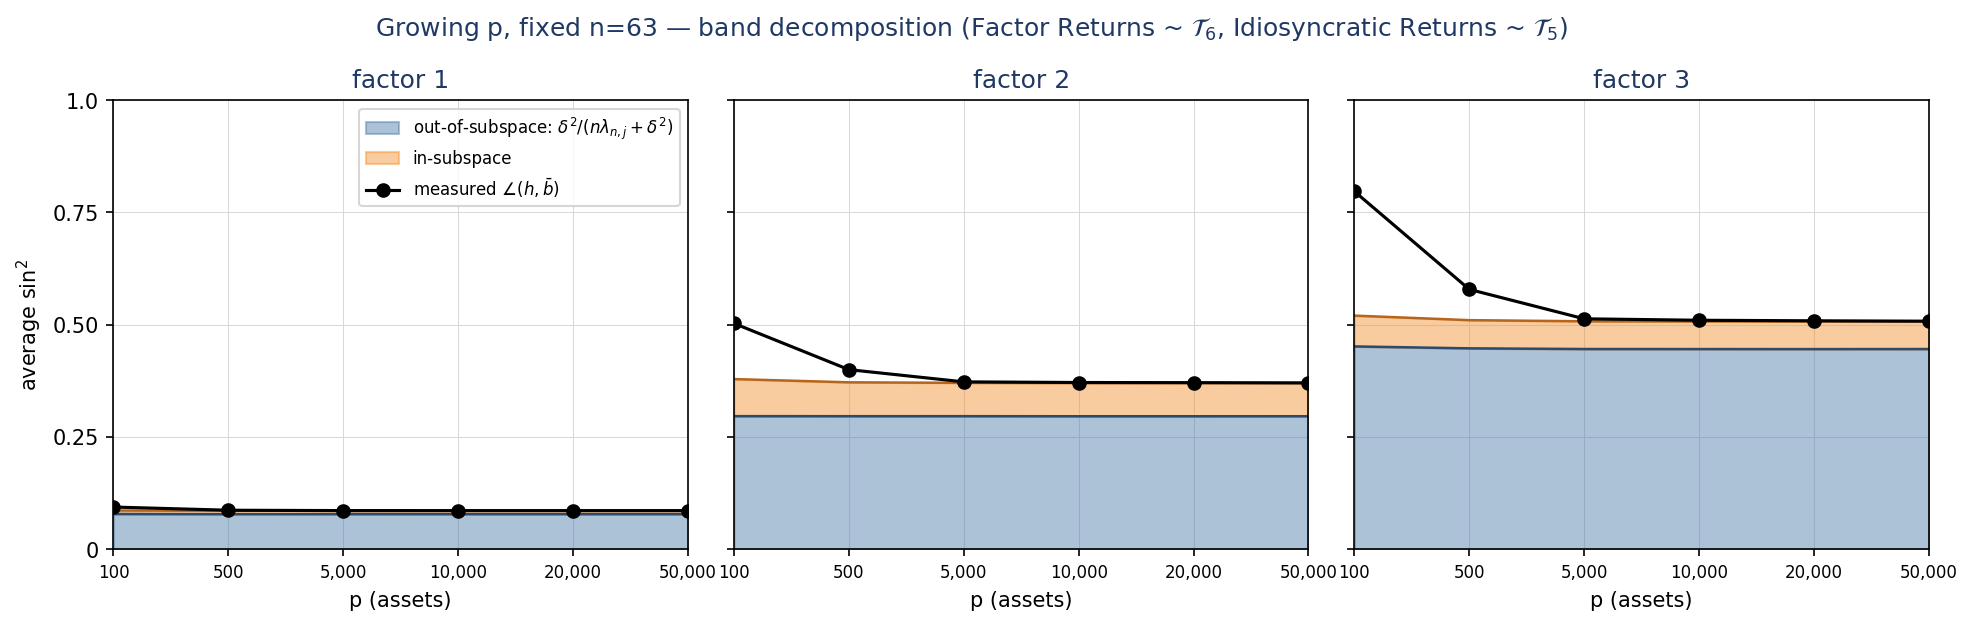

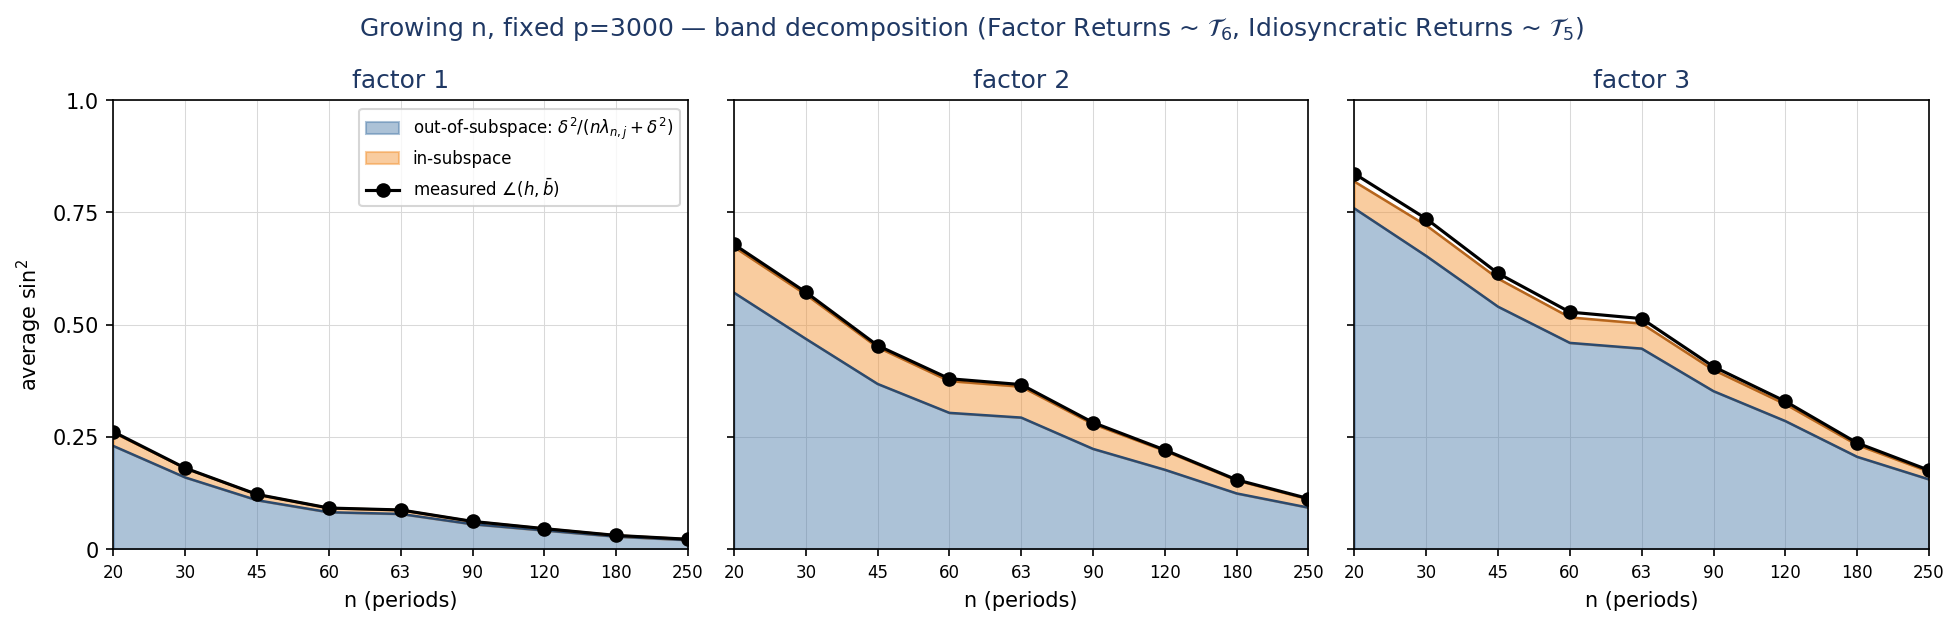

In [5]:
from fl_graphics import _np_summarize, _NP_NAVY, _NP_SIN2_TICKS


def top_row_decomposition_mono(df, *, key=None, suptitle=None, out_path=None):
    # Local copy of fl_graphics.top_row_decomposition: bands + measured dots, no CI caps.
    if key is None:
        key = "p" if df["p"].nunique() > 1 else "n"
    order = sorted(df[key].unique())
    cats = [f"{v:,}" for v in order] if key == "p" else [str(v) for v in order]
    xlabel = "p (assets)" if key == "p" else "n (periods)"
    avg = _np_summarize(df, key)
    fig, axes = plt.subplots(1, 3, figsize=(13.3, 4.4), sharey=True)
    fig.subplots_adjust(left=0.07, right=0.98, top=0.84, bottom=0.16, wspace=0.08)
    x = np.arange(len(cats))
    for j in (1, 2, 3):
        a = avg[avg["j"] == j].set_index(key).loc[order]
        ax = axes[j - 1]
        meas, oos, theory = (a["s2_meas"].to_numpy(), a["s2_oos"].to_numpy(),
                             a["s2_theory"].to_numpy())
        ax.fill_between(x, 0, oos, color="#4878a8", alpha=0.45,
                        label=r"out-of-subspace: $\delta^2/(n\lambda_{n,j}+\delta^2)$")
        ax.fill_between(x, oos, theory, color="#f28e2b", alpha=0.45, label="in-subspace")
        ax.plot(x, oos, "-", color="#2c4a6e", lw=1.2)
        ax.plot(x, theory, "-", color="#b5651d", lw=1.2)
        ax.plot(x, meas, "o-", color="black", label=r"measured $\angle(h, \bar b)$", zorder=5)
        ax.set_xlim(x[0], x[-1])
        ax.set_xticks(x, cats, fontsize=8)
        ax.set_title(f"factor {j}", color=_NP_NAVY)
        ax.set_xlabel(xlabel)
        ax.set_axisbelow(True)
        ax.grid(True, color="0.85", lw=0.5)
    axes[0].set_ylim(0, 1)
    axes[0].set_yticks(*_NP_SIN2_TICKS)
    axes[0].set_ylabel(r"average $\sin^2$")
    axes[0].legend(fontsize=8, loc="upper right")
    if suptitle:
        fig.suptitle(suptitle, color=_NP_NAVY, y=0.97)
    if out_path is not None:
        fig.savefig(str(out_path), dpi=150, bbox_inches="tight")
    return fig, axes

_band_p_png = OUT_DIR / "ex3_band_growing_p.png"
fig_band_p, _ = top_row_decomposition_mono(
    df_p, key="p", out_path=str(_band_p_png),
    suptitle=rf"Growing p, fixed n=63 — band decomposition "
             rf"(Factor Returns ~ {_ret_lab}, Idiosyncratic Returns ~ {_idio_lab})")
display(Image(filename=str(_band_p_png)))
plt.close(fig_band_p)

_band_n_png = OUT_DIR / "ex3_band_growing_n.png"
fig_band_n, _ = top_row_decomposition_mono(
    df_n, key="n", out_path=str(_band_n_png),
    suptitle=rf"Growing n, fixed p=3000 — band decomposition "
             rf"(Factor Returns ~ {_ret_lab}, Idiosyncratic Returns ~ {_idio_lab})")
display(Image(filename=str(_band_n_png)))
plt.close(fig_band_n)


## Figures 3–4 — pathwise difference boxplots

Per-replicate differences computed first, then boxplotted (each replicate is an
independent sample of the difference). Rows, per the (31) labels:

1. **Left − Middle** — `observable_floor_estimate − floor`
2. **Argument of right − Left** — `measured_out_of_subspace − observable_floor_estimate`
3. **Middle − Argument of right** — `floor − measured_out_of_subspace`

Columns are factors 1–3. Boxplot convention matches the existing gap boxplots
(`fl_graphics._np_gap_box_panel`): IQR box, 1.5·IQR whiskers, black median, dashed
zero reference. Y-limits auto-scale per row; the zero line is a reference, not an
assumed center. One figure per sweep.

In [6]:
from fl_graphics import _np_gap_box_panel, _NP_COLORS, _NP_NAVY

_DIFF_ROWS = [
    ("diff_left_middle", "Left − Middle",
     r"$\ell/\theta_j\; -\; \delta^2/(n\lambda_j^{(n)}+\delta^2)$"),
    ("diff_arg_left", "Argument of right − Left",
     r"$\Vert\Pi^{\perp}h_j\Vert^2\; -\; \ell/\theta_j$"),
    ("diff_middle_arg", "Middle − Argument of right",
     r"$\delta^2/(n\lambda_j^{(n)}+\delta^2)\; -\; \Vert\Pi^{\perp}h_j\Vert^2$"),
]

def add_pathwise_differences(df):
    """Per-replicate differences of the three formula-(31) components."""
    return df.assign(
        diff_left_middle=df["observable_floor_estimate"] - df["floor"],
        diff_arg_left=df["measured_out_of_subspace"] - df["observable_floor_estimate"],
        diff_middle_arg=df["floor"] - df["measured_out_of_subspace"],
    )

def pathwise_boxplot_grid(df, swept_key, *, suptitle=None, out_path=None):
    """3×3 grid: rows = the three pairwise differences, columns = factors.
    Each panel boxplots the per-replicate difference at each swept value,
    reusing fl_graphics' gap-boxplot styling (dashed 0-line, IQR box, no fliers)."""
    rf = add_pathwise_differences(df)
    factors = [1, 2, 3]
    order = sorted(rf[swept_key].unique())
    cats = [f"{v:,}" for v in order] if swept_key == "p" else [str(v) for v in order]
    x = np.arange(len(order))
    xlabel = "p (assets)" if swept_key == "p" else "n (periods)"

    fig, axes = plt.subplots(3, 3, figsize=(13.3, 9.6), sharex="col", sharey="row")
    fig.subplots_adjust(left=0.09, right=0.97, top=0.90, bottom=0.09,
                        hspace=0.14, wspace=0.08)
    for row, (col_name, row_label, row_math) in enumerate(_DIFF_ROWS):
        for col, j in enumerate(factors):
            ax = axes[row, col]
            sub = rf[rf["j"] == j]
            gaps = [sub.loc[sub[swept_key] == v, col_name].to_numpy() for v in order]
            _np_gap_box_panel(ax, gaps, x, cats, MONO)
            ax.set_axisbelow(True)
            ax.grid(True, color="0.85", lw=0.5)
            if row == 0:
                ax.set_title(f"factor {j}", color=_NP_NAVY)
            if row == 2:
                ax.set_xlabel(xlabel)
            else:
                ax.tick_params(labelbottom=False)
        axes[row, 0].set_ylabel(f"{row_label}\n{row_math}", fontsize=9)
    if suptitle:
        fig.suptitle(suptitle, color=_NP_NAVY, y=0.985)
    fig.text(0.5, 0.015,
             "per-replicate difference per swept value: box = IQR, whiskers 1.5·IQR, "
             f"line = median; dashed 0 = components agree (R = {N_REPS}).",
             ha="center", fontsize=7, color="0.35")
    if out_path is not None:
        fig.savefig(str(out_path), dpi=150, bbox_inches="tight")
    return fig, axes


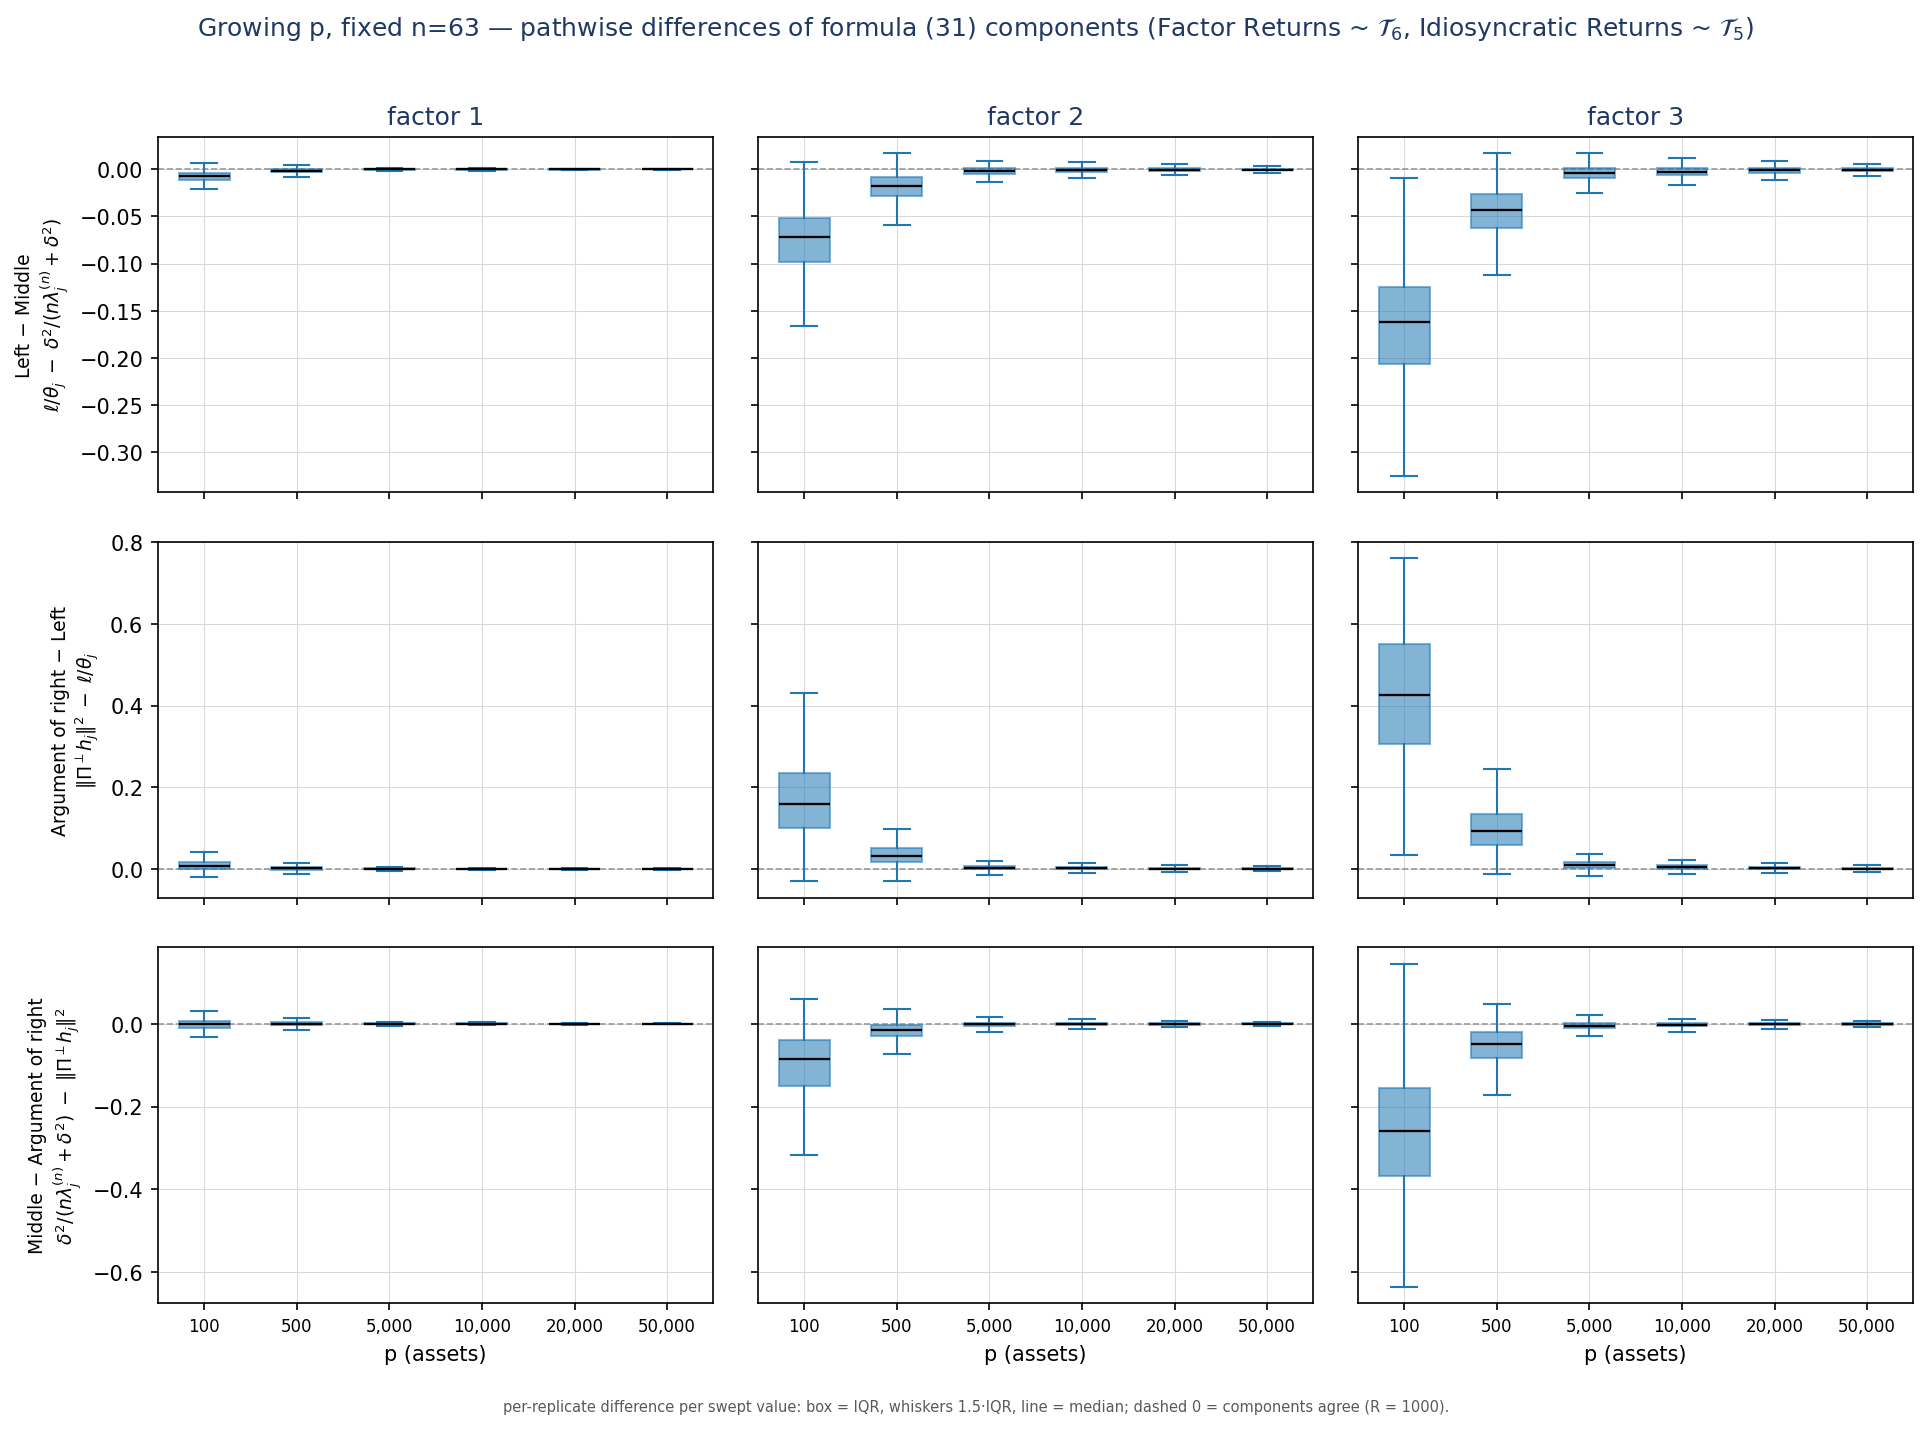

In [7]:
_box_p_png = OUT_DIR / "ex3_pathwise_boxplots_growing_p.png"
fig_box_p, _ = pathwise_boxplot_grid(
    df_p, "p", out_path=str(_box_p_png),
    suptitle=rf"Growing p, fixed n=63 — pathwise differences of formula (31) components "
             rf"(Factor Returns ~ {_ret_lab}, Idiosyncratic Returns ~ {_idio_lab})")
display(Image(filename=str(_box_p_png)))
plt.close(fig_box_p)


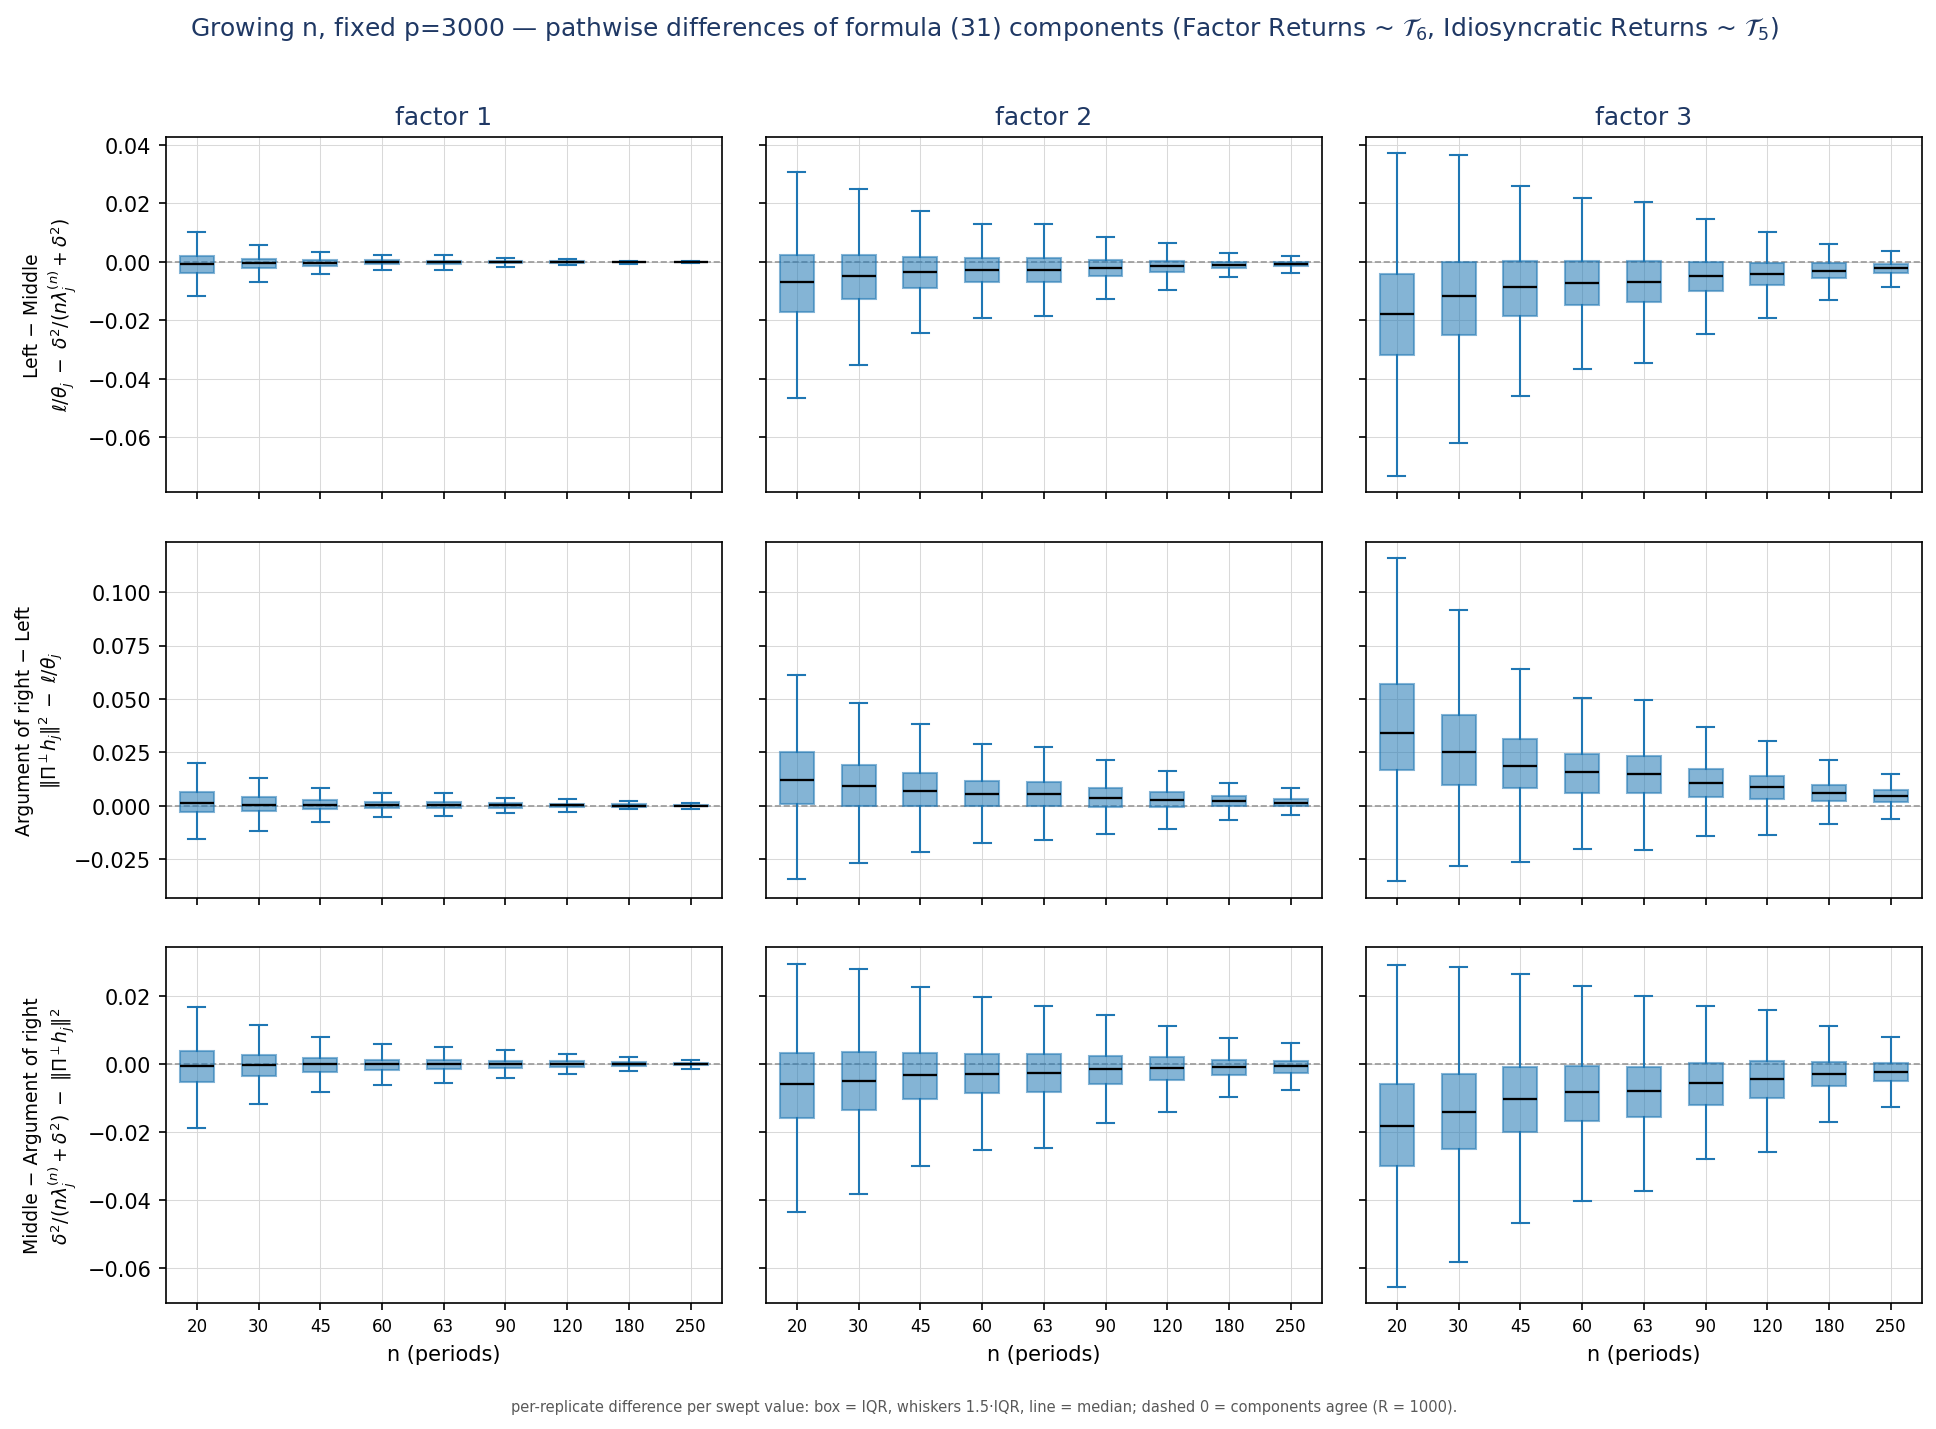

In [8]:
_box_n_png = OUT_DIR / "ex3_pathwise_boxplots_growing_n.png"
fig_box_n, _ = pathwise_boxplot_grid(
    df_n, "n", out_path=str(_box_n_png),
    suptitle=rf"Growing n, fixed p=3000 — pathwise differences of formula (31) components "
             rf"(Factor Returns ~ {_ret_lab}, Idiosyncratic Returns ~ {_idio_lab})")
display(Image(filename=str(_box_n_png)))
plt.close(fig_box_n)


## Numbers behind the boxplots

Median and IQR of each per-replicate difference, per (swept value, factor). Pathwise
convergence shows up as medians → 0 with shrinking IQRs.

In [9]:
def pathwise_difference_table(df, swept_key):
    rf = add_pathwise_differences(df)
    rows = []
    for col_name, row_label, _ in _DIFF_ROWS:
        g = rf.groupby([swept_key, "j"])[col_name]
        t = g.agg(median="median",
                  q25=lambda s: s.quantile(0.25),
                  q75=lambda s: s.quantile(0.75)).reset_index()
        t.insert(0, "difference", row_label)
        rows.append(t)
    out = pd.concat(rows, ignore_index=True)
    out["IQR"] = out["q75"] - out["q25"]
    return out

tbl_p = pathwise_difference_table(df_p, "p")
tbl_n = pathwise_difference_table(df_n, "n")
print("Growing p (n=63):")
display(tbl_p.round(5))
print("Growing n (p=3000):")
display(tbl_n.round(5))


Growing p (n=63):


,difference,p,j,median,q25,q75,IQR
0,Left − Middle,100,1,-0.00700,-0.01079,-0.00387,0.00692
1,Left − Middle,100,2,-0.07208,-0.09816,-0.05122,0.04693
2,Left − Middle,100,3,-0.16244,-0.20632,-0.12505,0.08127
3,Left − Middle,500,1,-0.00135,-0.00312,0.00001,0.00313
4,Left − Middle,500,2,-0.01794,-0.02812,-0.00775,0.02037
5,Left − Middle,500,3,-0.04330,-0.06225,-0.02595,0.03631
6,Left − Middle,5000,1,-0.00015,-0.00062,0.00033,0.00095
7,Left − Middle,5000,2,-0.00171,-0.00490,0.00097,0.00587
8,Left − Middle,5000,3,-0.00420,-0.00967,0.00126,0.01093
9,Left − Middle,10000,1,-0.00008,-0.00040,0.00024,0.00064


Growing n (p=3000):


,difference,n,j,median,q25,q75,IQR
0,Left − Middle,20,1,-0.00086,-0.00376,0.00185,0.00561
1,Left − Middle,20,2,-0.00685,-0.01725,0.00229,0.01954
2,Left − Middle,20,3,-0.01768,-0.03192,-0.00407,0.02785
3,Left − Middle,30,1,-0.00052,-0.00213,0.00113,0.00326
4,Left − Middle,30,2,-0.00476,-0.01268,0.00239,0.01508
...,...,...,...,...,...,...,...
76,Middle − Argument of right,180,2,-0.00095,-0.00322,0.00119,0.00441
77,Middle − Argument of right,180,3,-0.00299,-0.00654,0.00064,0.00718
78,Middle − Argument of right,250,1,-0.00001,-0.00041,0.00033,0.00075
79,Middle − Argument of right,250,2,-0.00070,-0.00255,0.00095,0.00350


In [10]:
#### SAVE FIGURES (PNG 300 dpi + PDF)
for fig_fn, base in [
    (lambda: top_row_decomposition_mono(df_p, key="p")[0], "ex3_band_growing_p"),
    (lambda: top_row_decomposition_mono(df_n, key="n")[0], "ex3_band_growing_n"),
    (lambda: pathwise_boxplot_grid(df_p, "p")[0], "ex3_pathwise_boxplots_growing_p"),
    (lambda: pathwise_boxplot_grid(df_n, "n")[0], "ex3_pathwise_boxplots_growing_n"),
]:
    fig = fig_fn()
    fig.savefig(OUT_DIR / f"{base}.png", dpi=300, bbox_inches="tight")
    fig.savefig(OUT_DIR / f"{base}.pdf", bbox_inches="tight")
    plt.close(fig)
print(f"saved 4 figures (png+pdf) to {OUT_DIR}")


saved 4 figures (png+pdf) to /Users/alex/Documents/Finance_Projects/factor_lab/nb_outputs/mono-ex3


## Figures 5–6 — two-row variant (shared y, sign-aligned)

Same pathwise boxplots restricted to the two comparisons against the observable
estimator, both oriented as **Left minus the other component**, so a positive box
means the observable estimate $\ell/\theta_j$ overshoots:

1. **Left − Middle** — `observable_floor_estimate − floor`
2. **Left − Argument of right** — `observable_floor_estimate − measured_out_of_subspace`

A single y-axis is shared across *all* panels (both rows), so the two differences are
read on one common scale. The 3×3 grids above are unchanged.

In [11]:
_DIFF_ROWS_2 = [
    ("diff_left_middle", "Left − Middle",
     r"$\ell/\theta_j\; -\; \delta^2/(n\lambda_j^{(n)}+\delta^2)$"),
    ("diff_left_arg", "Left − Argument of right",
     r"$\ell/\theta_j\; -\; \Vert\Pi^{\perp}h_j\Vert^2$"),
]

def add_pathwise_differences_2(df):
    """The two sign-aligned differences (Left minus the other component)."""
    return df.assign(
        diff_left_middle=df["observable_floor_estimate"] - df["floor"],
        diff_left_arg=df["observable_floor_estimate"] - df["measured_out_of_subspace"],
    )

def pathwise_boxplot_grid_2(df, swept_key, *, suptitle=None, out_path=None):
    """2×3 grid: rows = the two sign-aligned differences, columns = factors.
    Identical styling to pathwise_boxplot_grid, but a single y-axis is shared
    across ALL panels (sharey=True) so both rows read on the same scale."""
    rf = add_pathwise_differences_2(df)
    factors = [1, 2, 3]
    order = sorted(rf[swept_key].unique())
    cats = [f"{v:,}" for v in order] if swept_key == "p" else [str(v) for v in order]
    x = np.arange(len(order))
    xlabel = "p (assets)" if swept_key == "p" else "n (periods)"

    fig, axes = plt.subplots(2, 3, figsize=(13.3, 6.8), sharex="col", sharey=True)
    fig.subplots_adjust(left=0.09, right=0.97, top=0.88, bottom=0.11,
                        hspace=0.14, wspace=0.08)
    for row, (col_name, row_label, row_math) in enumerate(_DIFF_ROWS_2):
        for col, j in enumerate(factors):
            ax = axes[row, col]
            sub = rf[rf["j"] == j]
            gaps = [sub.loc[sub[swept_key] == v, col_name].to_numpy() for v in order]
            _np_gap_box_panel(ax, gaps, x, cats, MONO)
            ax.set_axisbelow(True)
            ax.grid(True, color="0.85", lw=0.5)
            if row == 0:
                ax.set_title(f"factor {j}", color=_NP_NAVY)
            if row == 1:
                ax.set_xlabel(xlabel)
            else:
                ax.tick_params(labelbottom=False)
        axes[row, 0].set_ylabel(f"{row_label}\n{row_math}", fontsize=9)
    if suptitle:
        fig.suptitle(suptitle, color=_NP_NAVY, y=0.985)
    fig.text(0.5, 0.015,
             "per-replicate difference per swept value: box = IQR, whiskers 1.5·IQR, "
             f"line = median; dashed 0 = components agree (R = {N_REPS}); "
             "one y-scale across all panels.",
             ha="center", fontsize=7, color="0.35")
    if out_path is not None:
        fig.savefig(str(out_path), dpi=150, bbox_inches="tight")
    return fig, axes

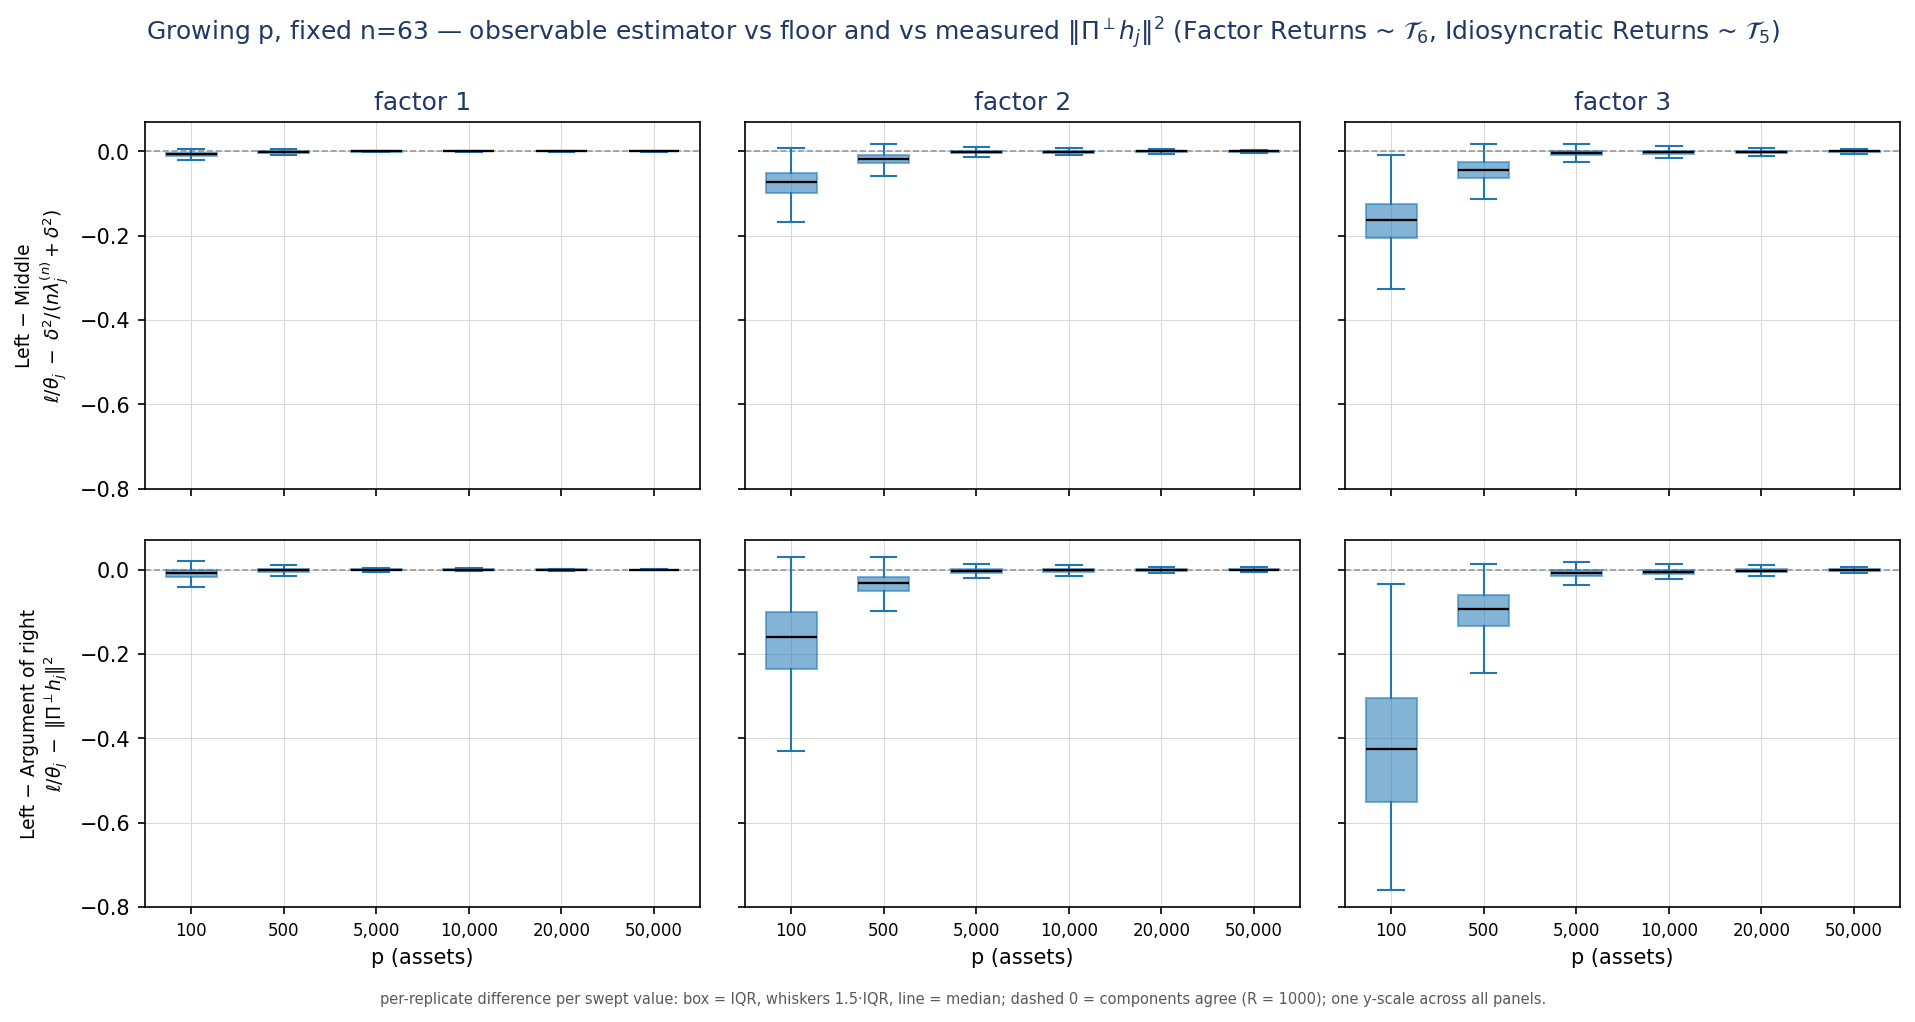

In [12]:
_box2_p_png = OUT_DIR / "ex3_pathwise_boxplots_2row_growing_p.png"
fig_box2_p, _ = pathwise_boxplot_grid_2(
    df_p, "p", out_path=str(_box2_p_png),
    suptitle=rf"Growing p, fixed n=63 — observable estimator vs floor and vs measured "
             rf"$\Vert\Pi^{{\perp}}h_j\Vert^2$ (Factor Returns ~ {_ret_lab}, "
             rf"Idiosyncratic Returns ~ {_idio_lab})")
fig_box2_p.savefig(OUT_DIR / "ex3_pathwise_boxplots_2row_growing_p.pdf", bbox_inches="tight")
display(Image(filename=str(_box2_p_png)))
plt.close(fig_box2_p)

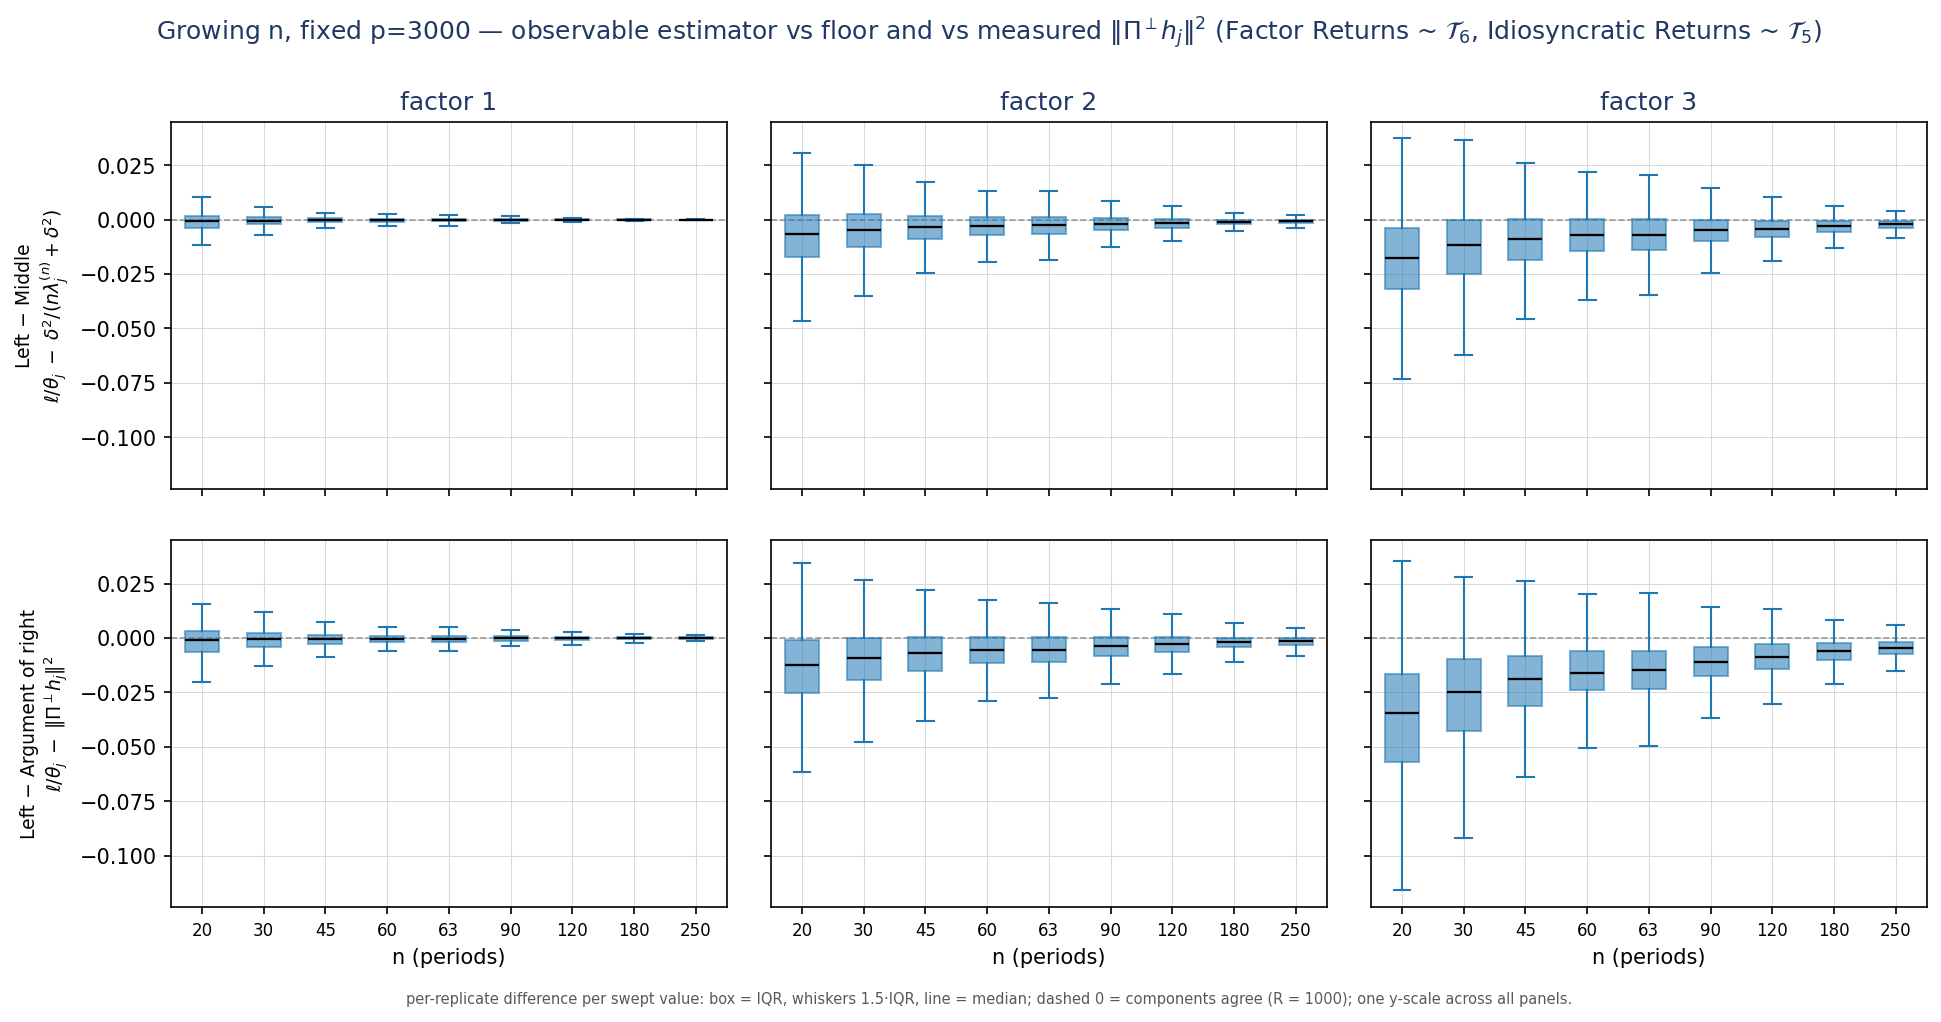

In [13]:
_box2_n_png = OUT_DIR / "ex3_pathwise_boxplots_2row_growing_n.png"
fig_box2_n, _ = pathwise_boxplot_grid_2(
    df_n, "n", out_path=str(_box2_n_png),
    suptitle=rf"Growing n, fixed p=3000 — observable estimator vs floor and vs measured "
             rf"$\Vert\Pi^{{\perp}}h_j\Vert^2$ (Factor Returns ~ {_ret_lab}, "
             rf"Idiosyncratic Returns ~ {_idio_lab})")
fig_box2_n.savefig(OUT_DIR / "ex3_pathwise_boxplots_2row_growing_n.pdf", bbox_inches="tight")
display(Image(filename=str(_box2_n_png)))
plt.close(fig_box2_n)

## Figures 7–8 — single-row variant (Left − Argument of right only)

The same two sweeps reduced to the one comparison of interest — the observable estimator
against the finite-$p$ measured out-of-subspace mass:

$$\ell^{(p,n)}/\theta_j^{(p,n)} \;-\; \lVert\Pi^{\perp}h_j\rVert^2$$

One panel per factor, per-replicate boxplots at each swept value, y shared across the
three panels. Same styling as Figures 5–6; positive means the observable estimate
overshoots the measured mass. Additive — Figures 5–6 above are unchanged.

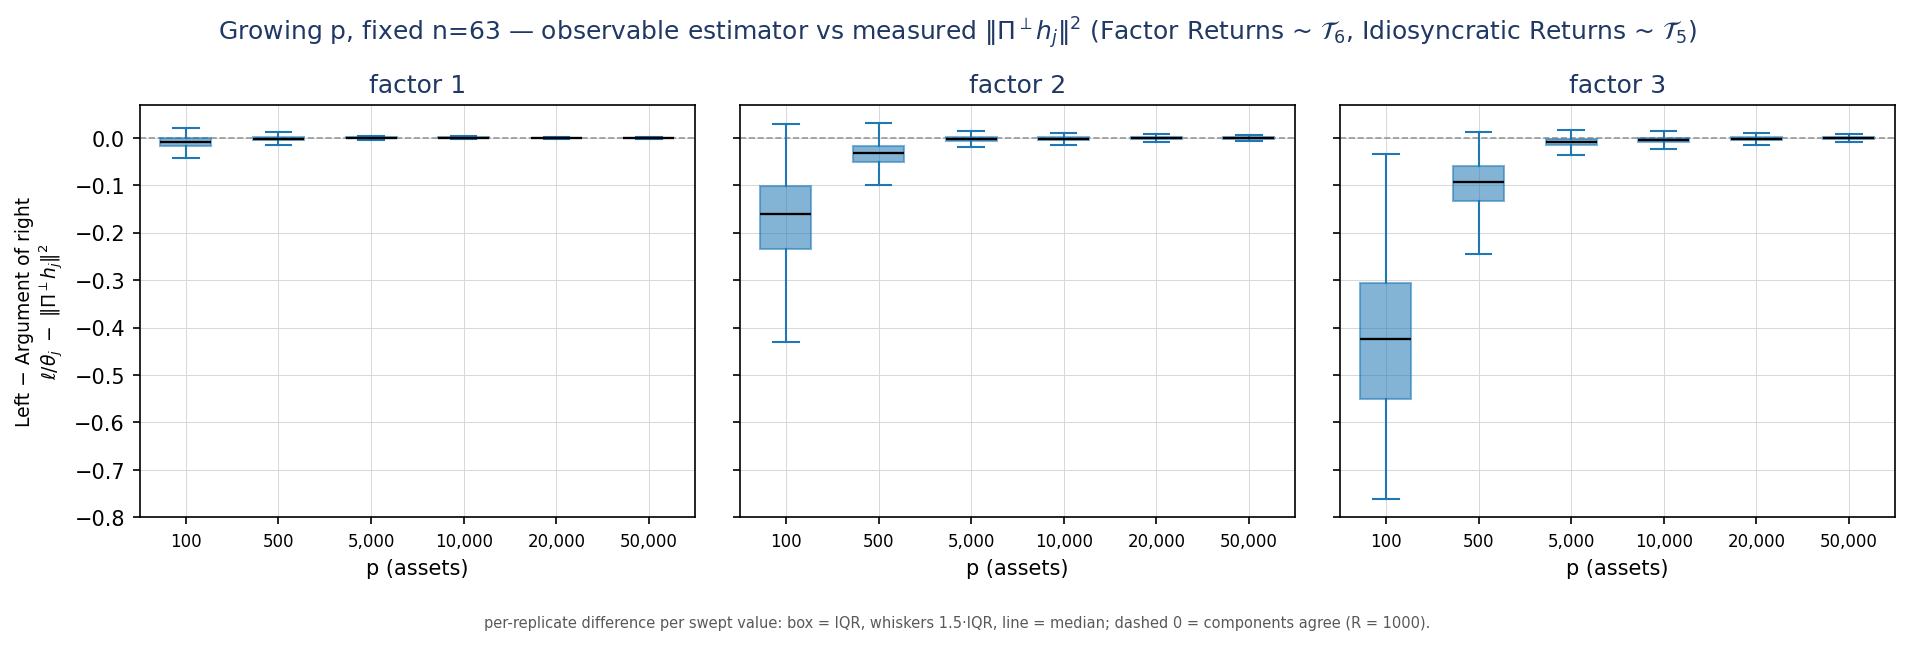

In [14]:
_DIFF_LEFT_ARG = ("diff_left_arg", "Left − Argument of right",
                  r"$\ell/\theta_j\; -\; \Vert\Pi^{\perp}h_j\Vert^2$")

def pathwise_boxplot_single(df, swept_key, *, suptitle=None, out_path=None):
    """1×3: only the Left − Argument-of-right difference, one panel per factor.
    Identical styling to pathwise_boxplot_grid_2 (same _np_gap_box_panel, dashed 0-line,
    shared y across the three factor panels)."""
    rf = add_pathwise_differences_2(df)
    col_name, row_label, row_math = _DIFF_LEFT_ARG
    factors = [1, 2, 3]
    order = sorted(rf[swept_key].unique())
    cats = [f"{v:,}" for v in order] if swept_key == "p" else [str(v) for v in order]
    x = np.arange(len(order))
    xlabel = "p (assets)" if swept_key == "p" else "n (periods)"

    fig, axes = plt.subplots(1, 3, figsize=(13.3, 4.3), sharex=True, sharey=True)
    fig.subplots_adjust(left=0.09, right=0.97, top=0.83, bottom=0.19, wspace=0.08)
    for col, j in enumerate(factors):
        ax = axes[col]
        sub = rf[rf["j"] == j]
        gaps = [sub.loc[sub[swept_key] == v, col_name].to_numpy() for v in order]
        _np_gap_box_panel(ax, gaps, x, cats, MONO)
        ax.set_axisbelow(True)
        ax.grid(True, color="0.85", lw=0.5)
        ax.set_title(f"factor {j}", color=_NP_NAVY)
        ax.set_xlabel(xlabel)
    axes[0].set_ylabel(f"{row_label}\n{row_math}", fontsize=9)
    if suptitle:
        fig.suptitle(suptitle, color=_NP_NAVY, y=0.97)
    fig.text(0.5, 0.02,
             "per-replicate difference per swept value: box = IQR, whiskers 1.5·IQR, "
             f"line = median; dashed 0 = components agree (R = {N_REPS}).",
             ha="center", fontsize=7, color="0.35")
    if out_path is not None:
        fig.savefig(str(out_path), dpi=150, bbox_inches="tight")
    return fig, axes


_box1_p_png = OUT_DIR / "ex3_pathwise_boxplots_1row_growing_p.png"
fig_box1_p, _ = pathwise_boxplot_single(
    df_p, "p", out_path=str(_box1_p_png),
    suptitle=rf"Growing p, fixed n=63 — observable estimator vs measured "
             rf"$\Vert\Pi^{{\perp}}h_j\Vert^2$ (Factor Returns ~ {_ret_lab}, "
             rf"Idiosyncratic Returns ~ {_idio_lab})")
fig_box1_p.savefig(OUT_DIR / "ex3_pathwise_boxplots_1row_growing_p.pdf", bbox_inches="tight")
display(Image(filename=str(_box1_p_png)))
plt.close(fig_box1_p)

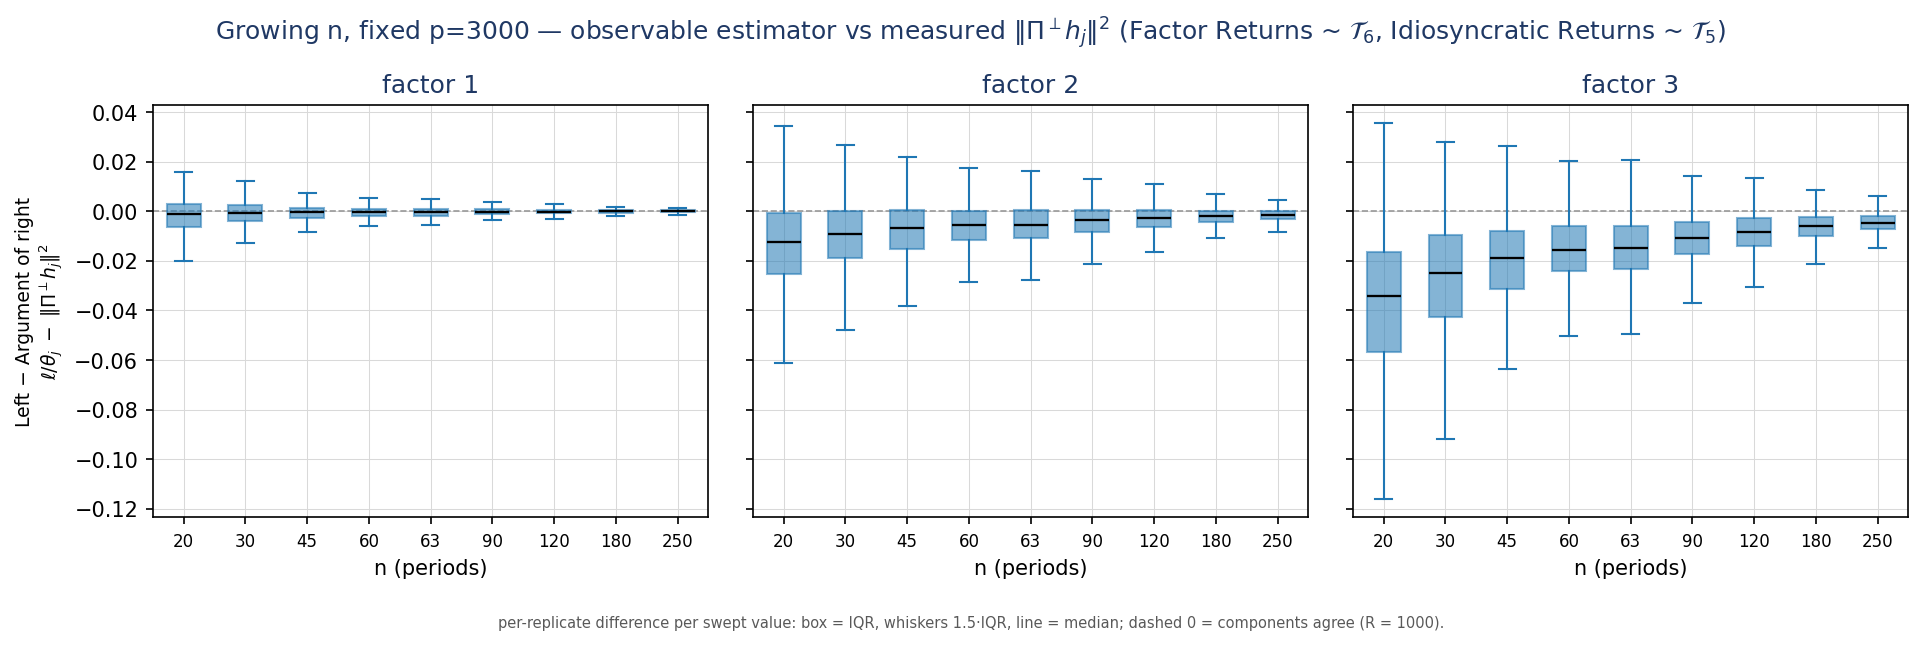

In [15]:
_box1_n_png = OUT_DIR / "ex3_pathwise_boxplots_1row_growing_n.png"
fig_box1_n, _ = pathwise_boxplot_single(
    df_n, "n", out_path=str(_box1_n_png),
    suptitle=rf"Growing n, fixed p=3000 — observable estimator vs measured "
             rf"$\Vert\Pi^{{\perp}}h_j\Vert^2$ (Factor Returns ~ {_ret_lab}, "
             rf"Idiosyncratic Returns ~ {_idio_lab})")
fig_box1_n.savefig(OUT_DIR / "ex3_pathwise_boxplots_1row_growing_n.pdf", bbox_inches="tight")
display(Image(filename=str(_box1_n_png)))
plt.close(fig_box1_n)

---
## Component-colored versions

Every pathwise difference in this notebook compares **out-of-subspace** quantities
(observable estimate, analytic floor, measured $\Vert\Pi^\perp h_j\Vert^2$), so in the
component palette all boxes take the out-of-subspace blue (`#4878a8`) — the same color as
the out-of-subspace band fill in Figures 1–2, tying the boxplots to the band visually.

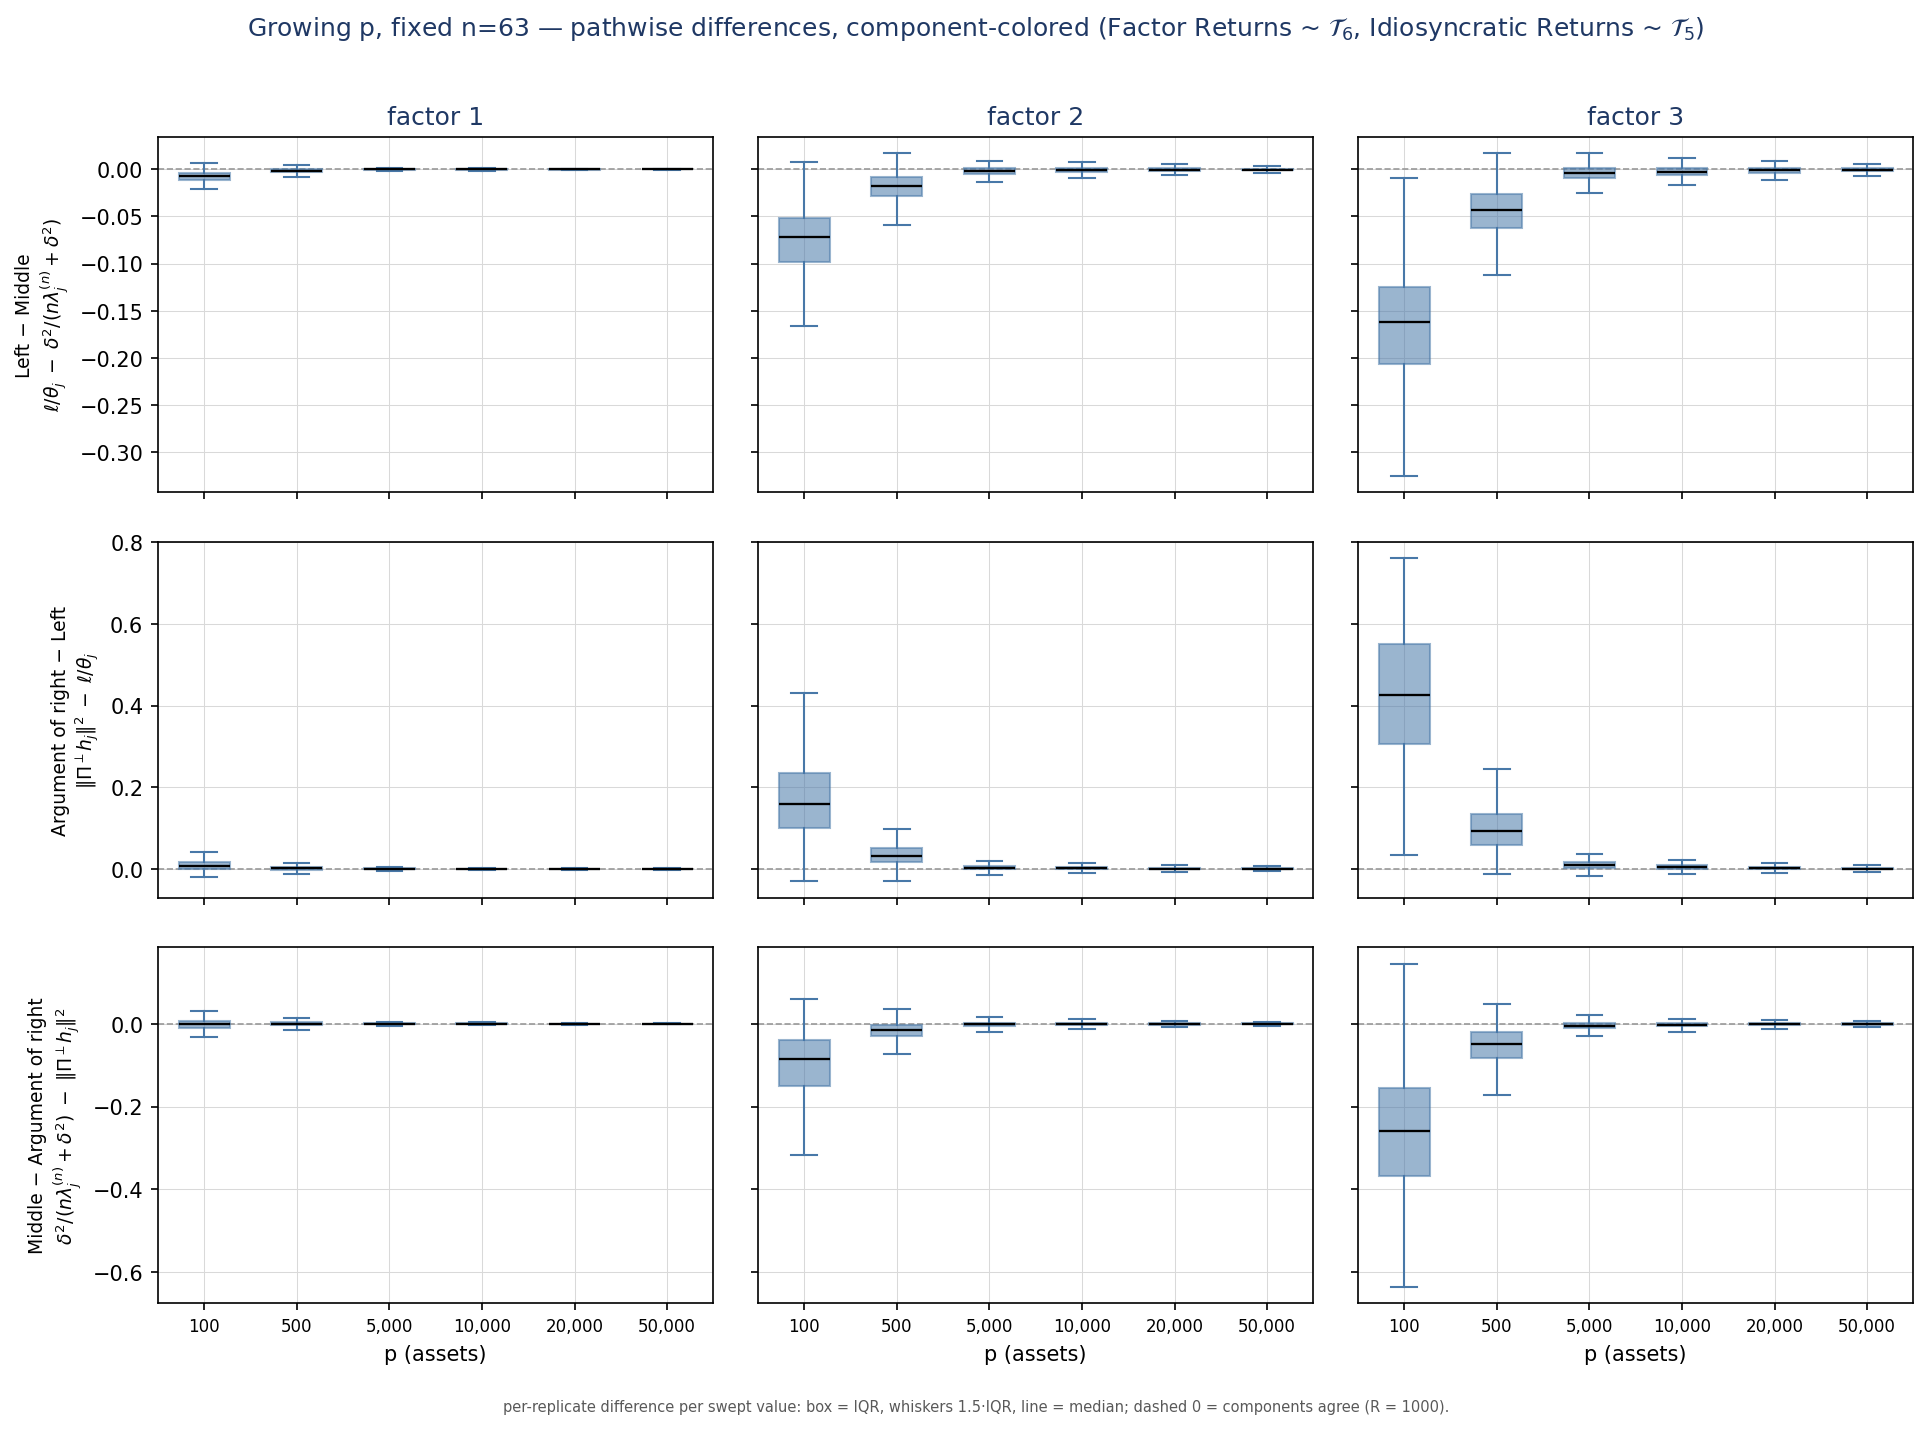

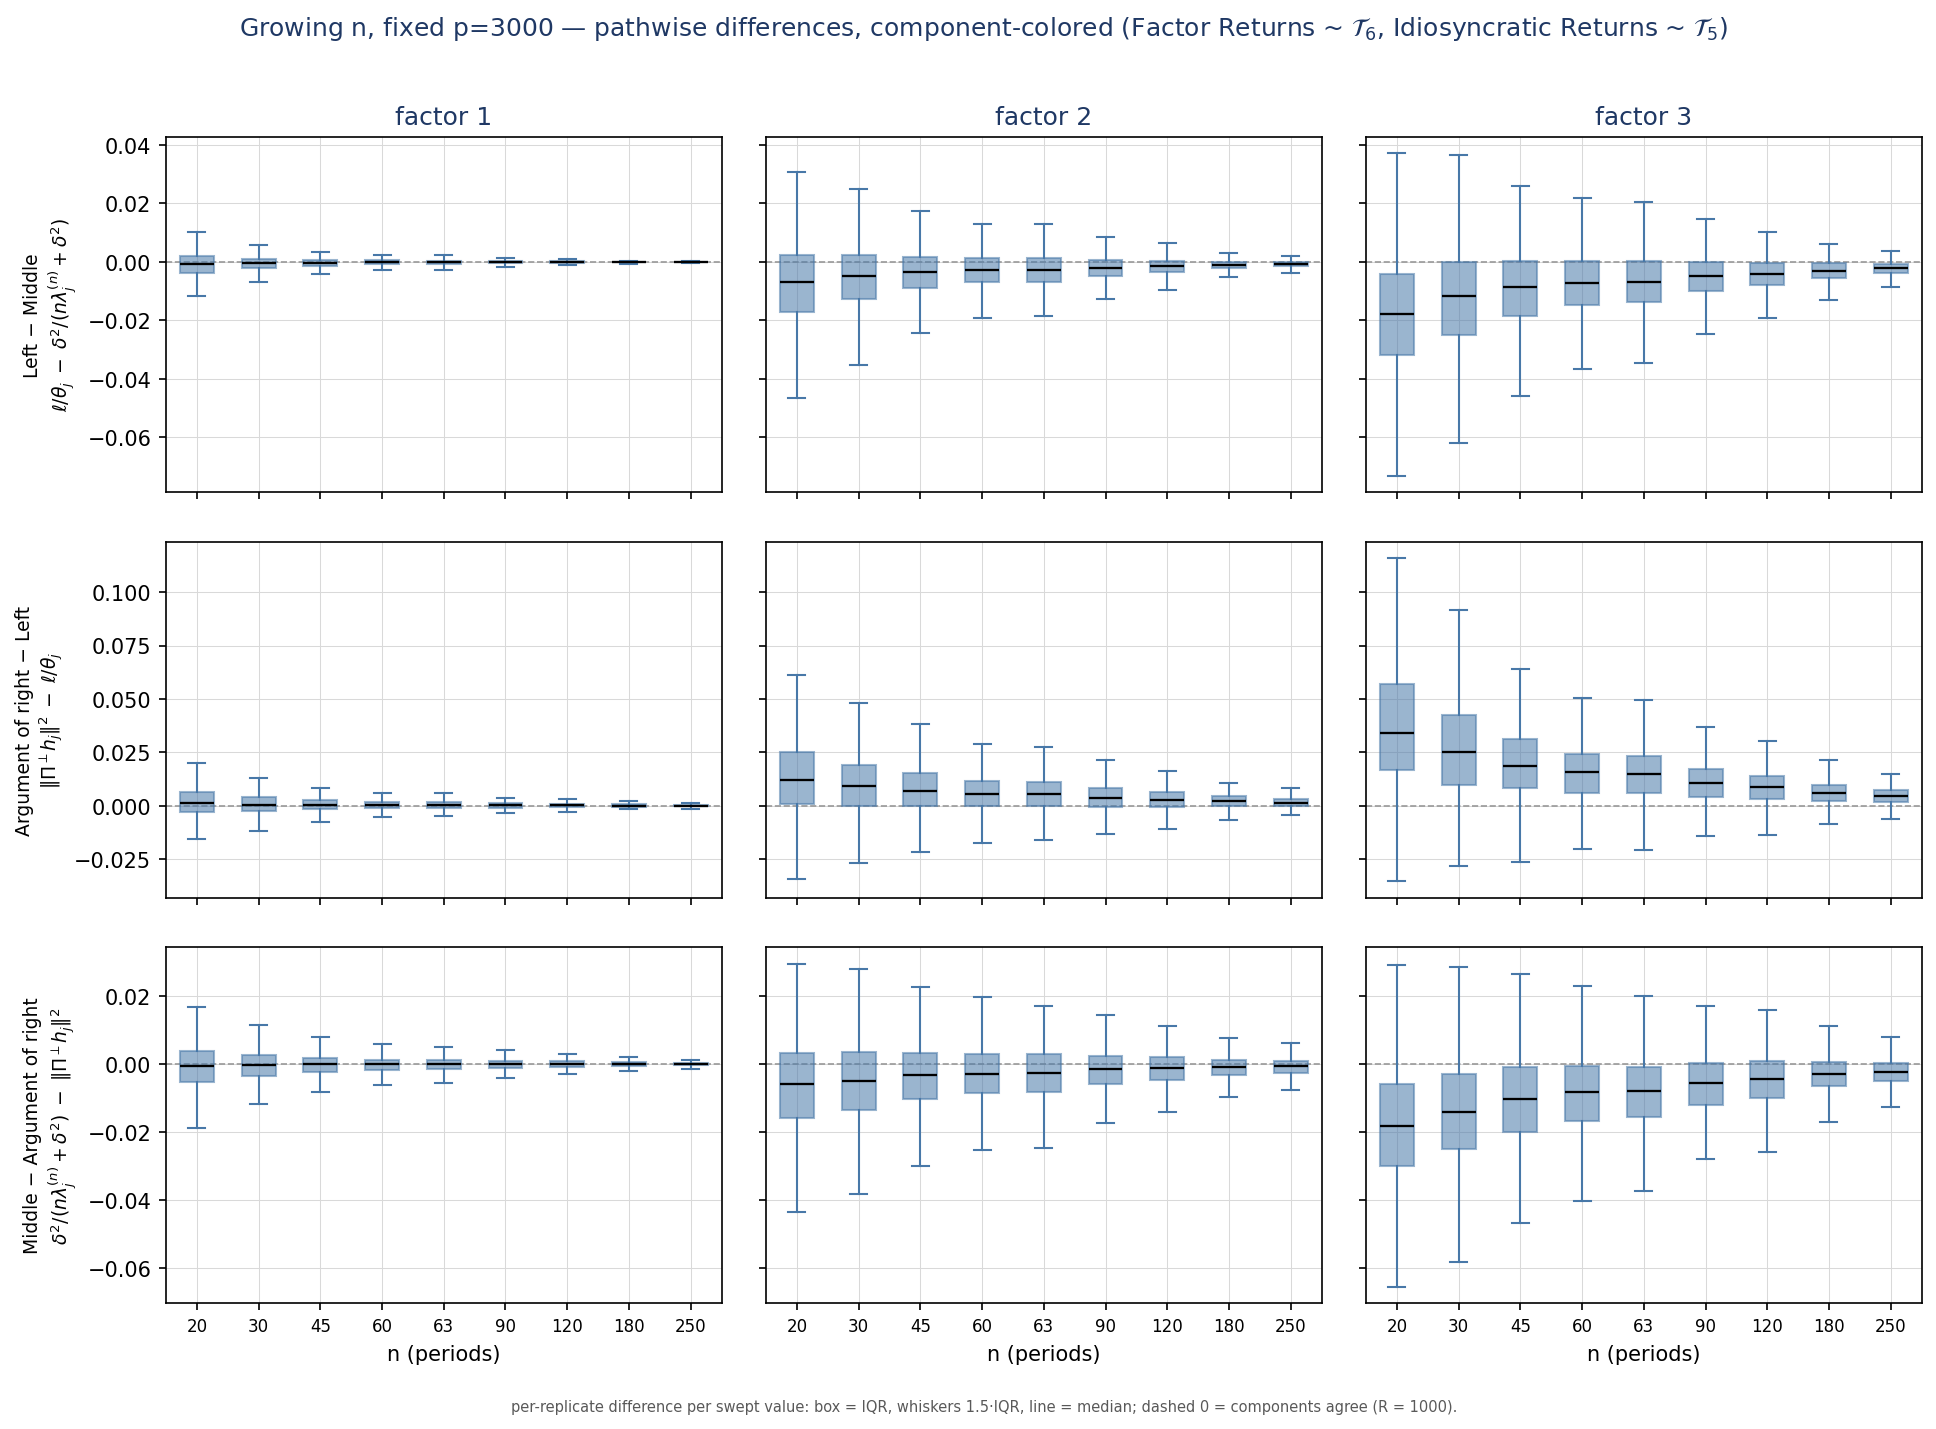

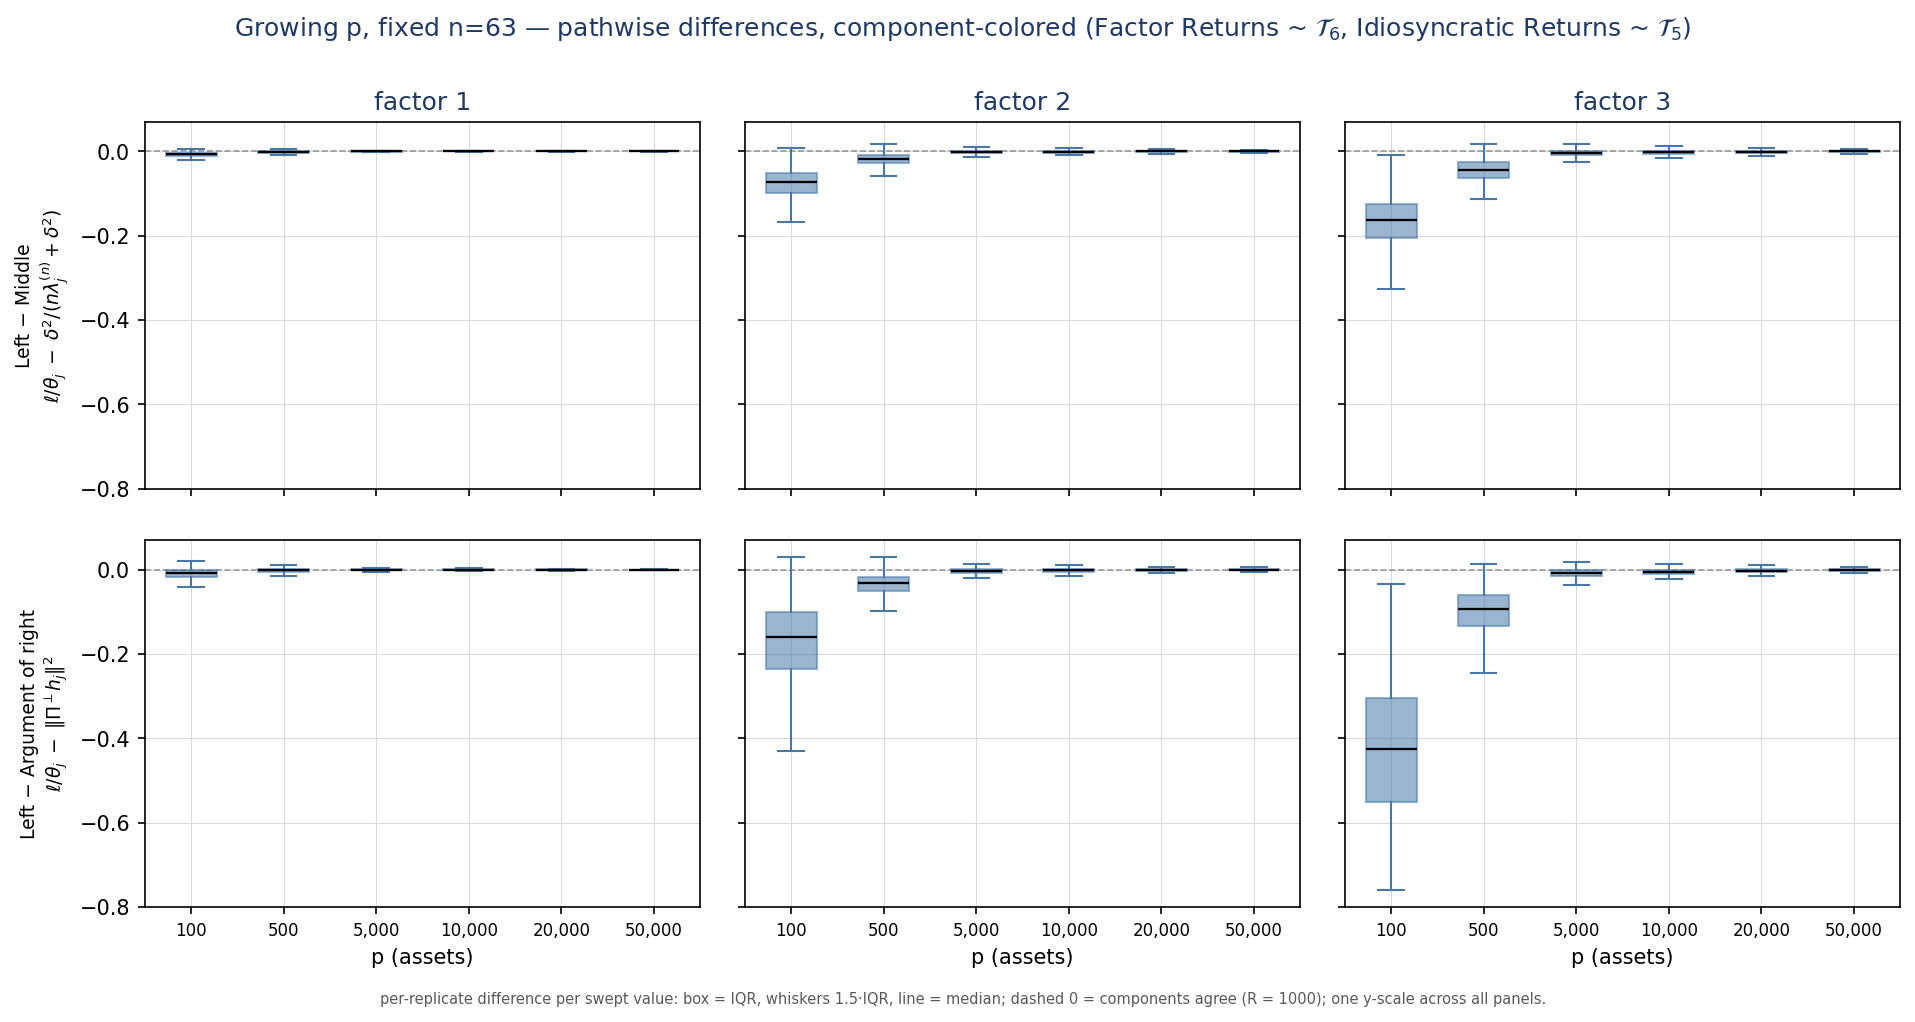

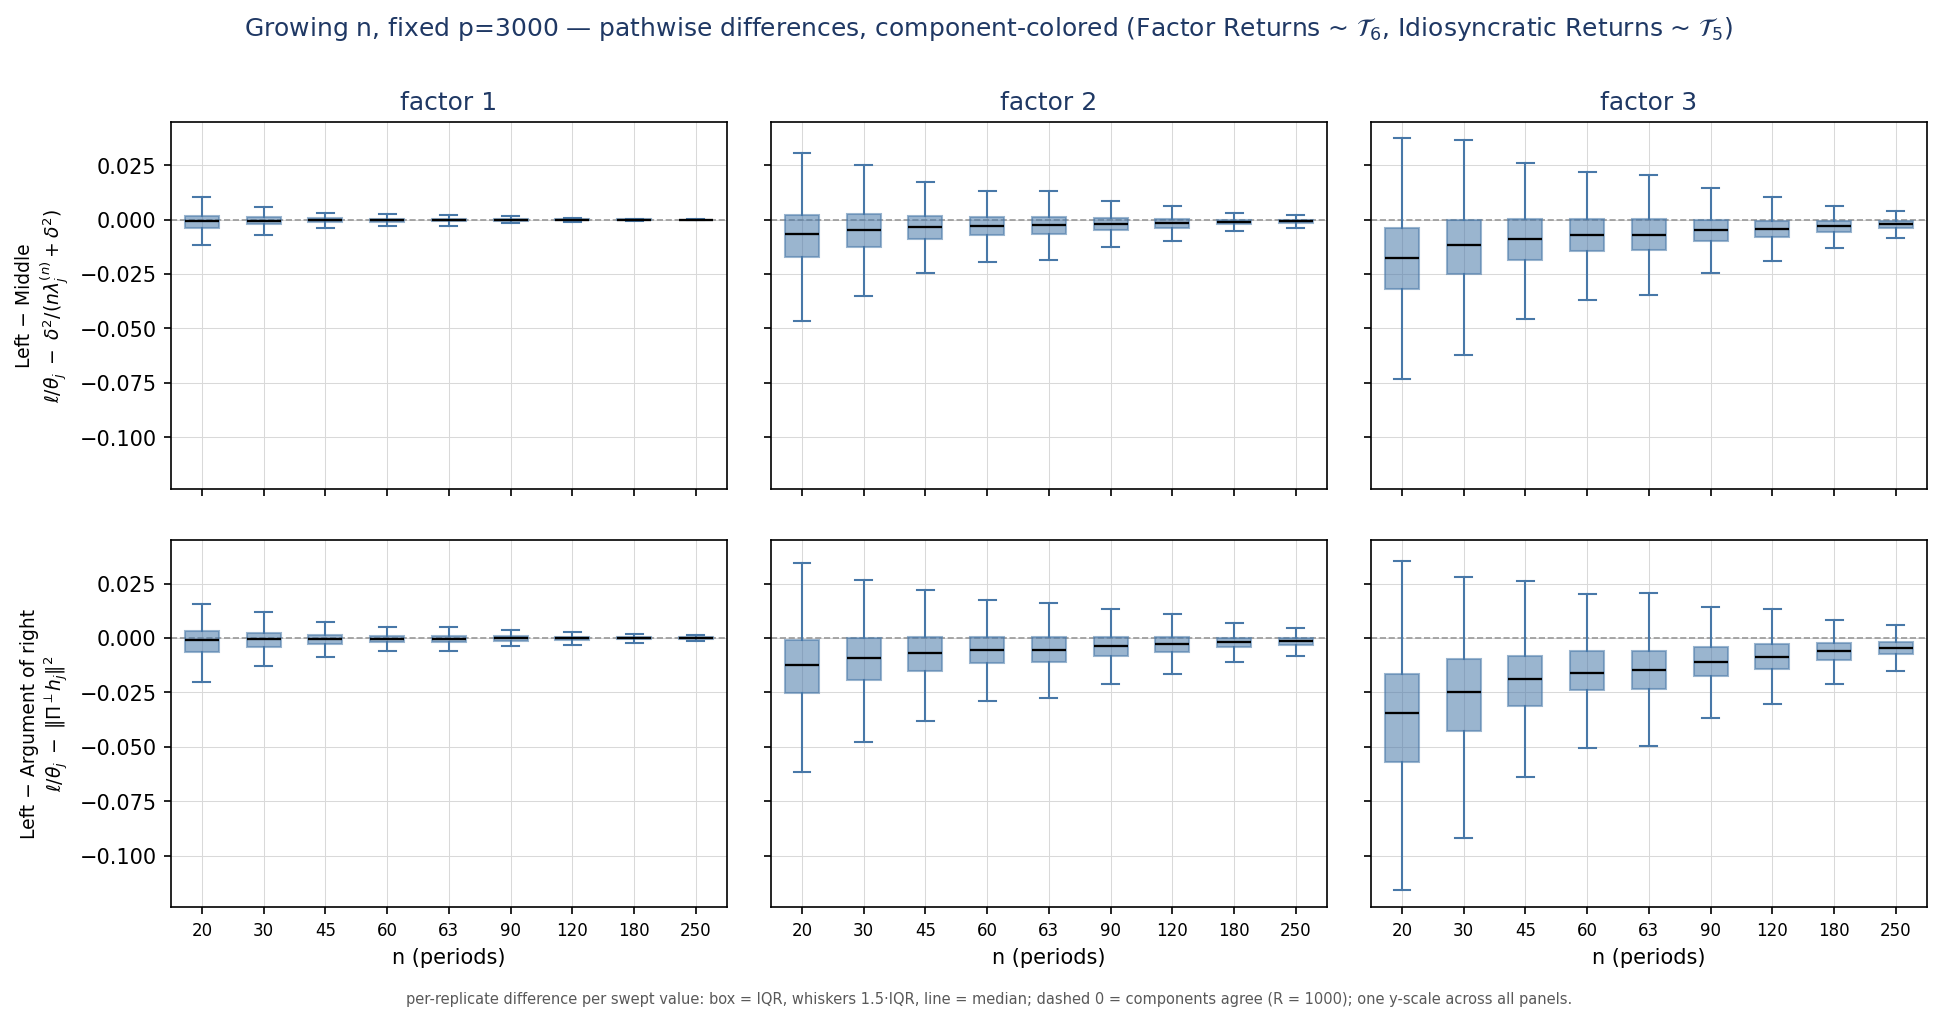

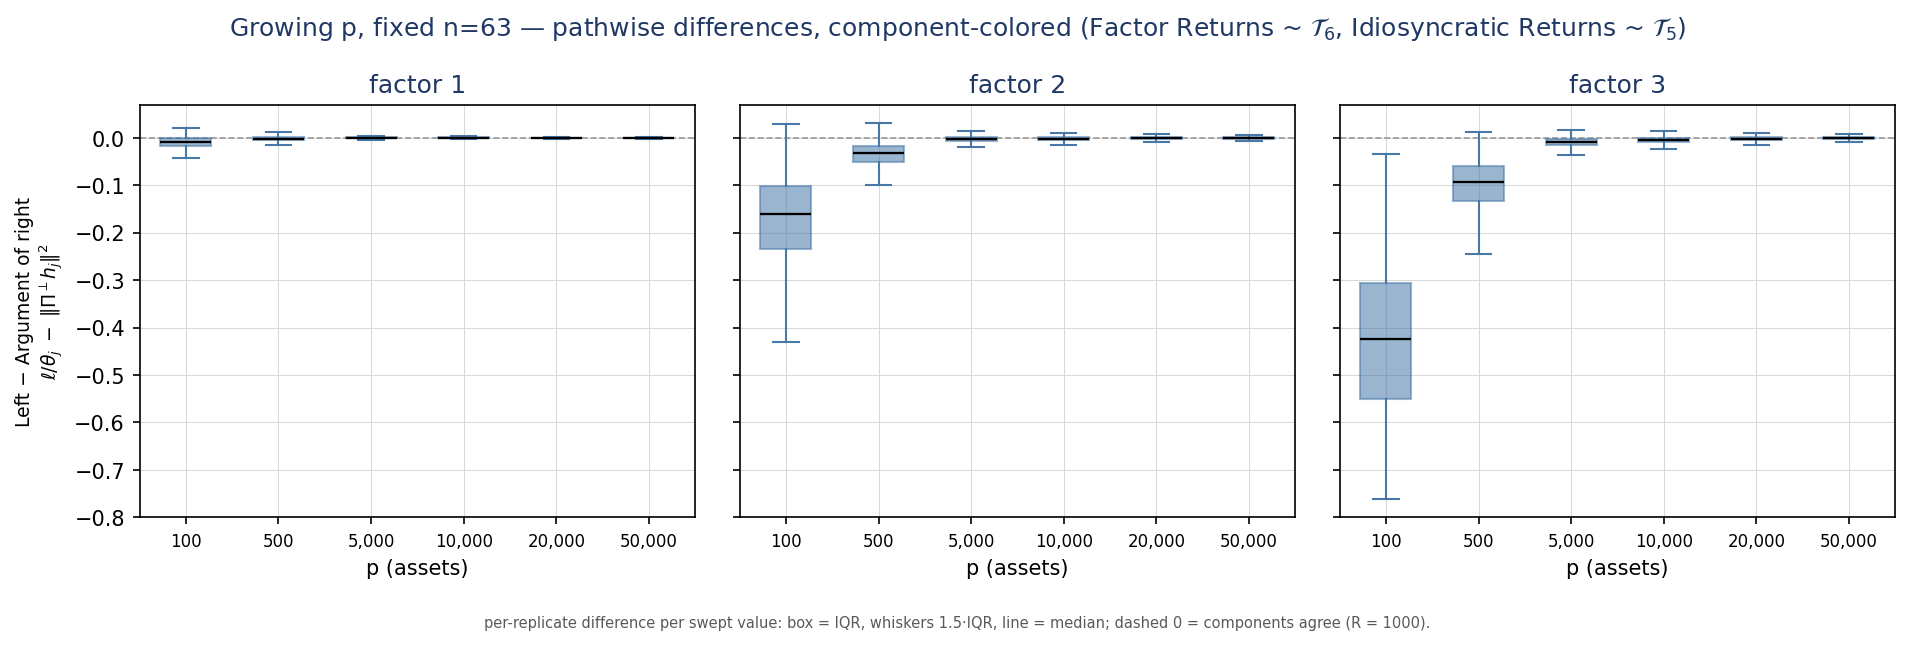

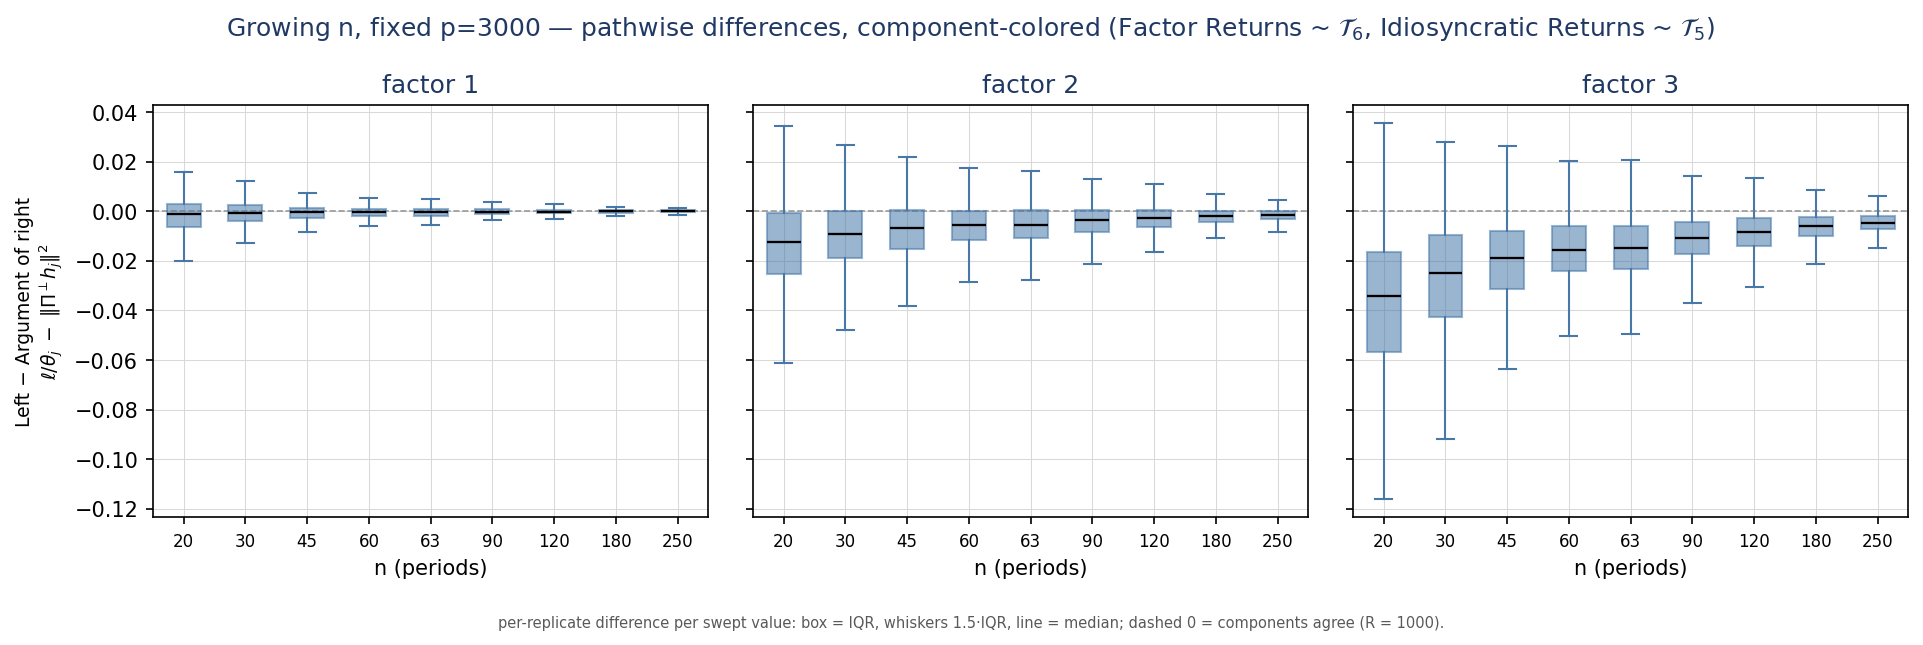

In [16]:
# all quantities here are out-of-subspace comparisons -> band blue for every box.
# The grid plotters take their box color from the notebook-global MONO; rebind + restore.
COMP_OOS = "#4878a8"
_keep, MONO = MONO, COMP_OOS
try:
    for fn, df, key, stem in [
            (pathwise_boxplot_grid, df_p, "p", "ex3_pathwise_boxplots_qcolor_growing_p"),
            (pathwise_boxplot_grid, df_n, "n", "ex3_pathwise_boxplots_qcolor_growing_n"),
            (pathwise_boxplot_grid_2, df_p, "p", "ex3_pathwise_boxplots_2row_qcolor_growing_p"),
            (pathwise_boxplot_grid_2, df_n, "n", "ex3_pathwise_boxplots_2row_qcolor_growing_n"),
            (pathwise_boxplot_single, df_p, "p", "ex3_pathwise_boxplots_1row_qcolor_growing_p"),
            (pathwise_boxplot_single, df_n, "n", "ex3_pathwise_boxplots_1row_qcolor_growing_n")]:
        _png = OUT_DIR / f"{stem}.png"
        lab = "Growing p, fixed n=63" if key == "p" else "Growing n, fixed p=3000"
        fig, _ = fn(df, key, out_path=str(_png),
                    suptitle=rf"{lab} — pathwise differences, component-colored "
                             rf"(Factor Returns ~ {_ret_lab}, Idiosyncratic Returns ~ {_idio_lab})")
        display(Image(filename=str(_png)))
        plt.close(fig)
finally:
    MONO = _keep


---
## Change log

- **mono duplicate**: single color for all per-factor boxplots; band-figure measured dots
  without CI caps (local `top_row_decomposition_mono`); sweeps loaded from the shared
  ex2v2 cache.

- New standalone notebook; nothing in ex-2c or any `.py` file modified.
- `ObservableSpectrumAnalysis` / `ObservableFloorExperiment` carried over verbatim
  from ex-2c, centering caveat included ($n-k-1$ bulk eigenvalues under `center=True`).
- New `MeasuredDecompositionAnalysis` / `MeasuredDecompositionExperiment` subclasses
  add `measured_out_of_subspace` ($\lVert\Pi^{\perp}h_j\rVert^2$ at finite $p$, eq. 18)
  and `measured_in_subspace` per replicate.
- Two sweeps (growing $p$, $n=63$; growing $n$, $p=3000$; $R=1000$, same seed as
  ex-2c) computed once and reused by all figures/tables.
- Figures 1–2: `top_row_decomposition` unchanged, new frames.
- Figures 3–4: 3×3 pathwise-difference boxplot grids (Left−Middle, Argument−Left,
  Middle−Argument), styling via `fl_graphics._np_gap_box_panel`.
- **2026-07-19**: added Figures 5–6 — two-row variant of the pathwise grids
  (Left−Middle and sign-flipped Left−Argument; third row dropped) with a single
  y-axis shared across all panels. Additive only — the 3×3 grids are unchanged.
- **2026-07-22**: added Figures 7–8 — single-row variant of the same sweeps showing
  only **Left − Argument of right** ($\ell/\theta_j - \lVert\Pi^{\perp}h_j\rVert^2$),
  one panel per factor, y shared across panels (`pathwise_boxplot_single`). Additive —
  Figures 5–6 unchanged. Also repaired a duplicated change-log cell that had displaced
  the Figures 5–6 section header.